# Introduction
Global warming has been the hot topic in the World Health Organisation (WHO) for many years. Vehicle emissions are a major source of environmental pollution and climate change, with carbon dioxide (CO2) and nitrogen oxides (NOX) being among the most significant pollutants. According to European Environment Agency (2023), CO2 has impacted the increase of temperature, while NOX emissions are associated with smog formation, acid rain, and adverse respiratory effects. Hence, the Intergovernmental Panel on Climate Change (IPCC) has suggested to closely monitor the gas emissions from the road vehicles. 

This report analyses emissions using the data from the UK Vehicle Certification Agency (VCA), which provides verified measurements of vehicle fuel consumption and emissions under the Worldwide Harmonised Light Vehicle Test Procedure (WLTP). The VCA dataset ensures consistency and accuracy across vehicle testing in accordance with European and international standards (UK Vehicle Certification Agency 2024). Through statistical and predictive modelling, this study explores the key factors influencing emission levels to support sustainable transportation research and evidence-based environmental policymaking.

In [875]:
# Install Package 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import math

from numpy.random import normal

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import  StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Exploratory Data Analysis
The data set contains of 3702 vehicles from different companies and 19 columns of measurement of vehicle types, fuel consumption and emmission. 

| Category  | Columns |
|-----------|-----------|
| Vehicle   | Manufacturer, Model, Description, Transmission, Manual or Automatic, Engine Capacity, Fuel Type, Powertrain, Engine Power (PS),  Engine Power (Kw)|
| Fuel Consumption     |   Diesel VED Supplement, Testing Scheme, WLTP Imperial Low, WLTP Imperial Medium, WLTP Imperial High, WLTP Imperial Extra High, WLTP Imperial Combined, WLTP Imperial Combined (Weighted), WLTP Metric Low, WLTP Metric Medium,  WLTP Metric High, WLTP Metric Extra High, WLTP Metric Combined, WLTP Metric Combined (Weighted), WLTP CO2, WLTP CO2 Weighted |
| Electric Consumption | Electric energy consumption Miles/kWh, wh/km ,Maximum range (Km), Maximum range (Miles), Equivalent All Electric Range Miles, Equivalent All Electric Range KM, Electric Range City Miles |
| Standard  | Euro Standard | 
| Emmission | Emissions CO [mg/km], THC Emissions [mg/km], Emissions NOx [mg/km], THC + NOx Emissions [mg/km], Particulates [No.] [mg/km], RDE NOx Urban, RDE NOx Combined, Noise Level dB(A) |
| Date | Date of change |


Out of the 19 columns only 3 columns which are Manual or Automatic, Fuel Type, and Powertrain are in non-numeric data type, the rest of columns are numeric. From following chart, we can see the distribution of fuel type of the vehicle in the data set. We can group the vehicles into three main categories: Fuel, Hybrid and Electric.



In [876]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head();
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'


# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

In [877]:
print(f"Original data shape: {data.shape}");
print(f"Data rows: {data.shape[0]}, Data columns: {data.shape[1]}");

Original data shape: (3702, 44)
Data rows: 3702, Data columns: 44


In [878]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

In [879]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


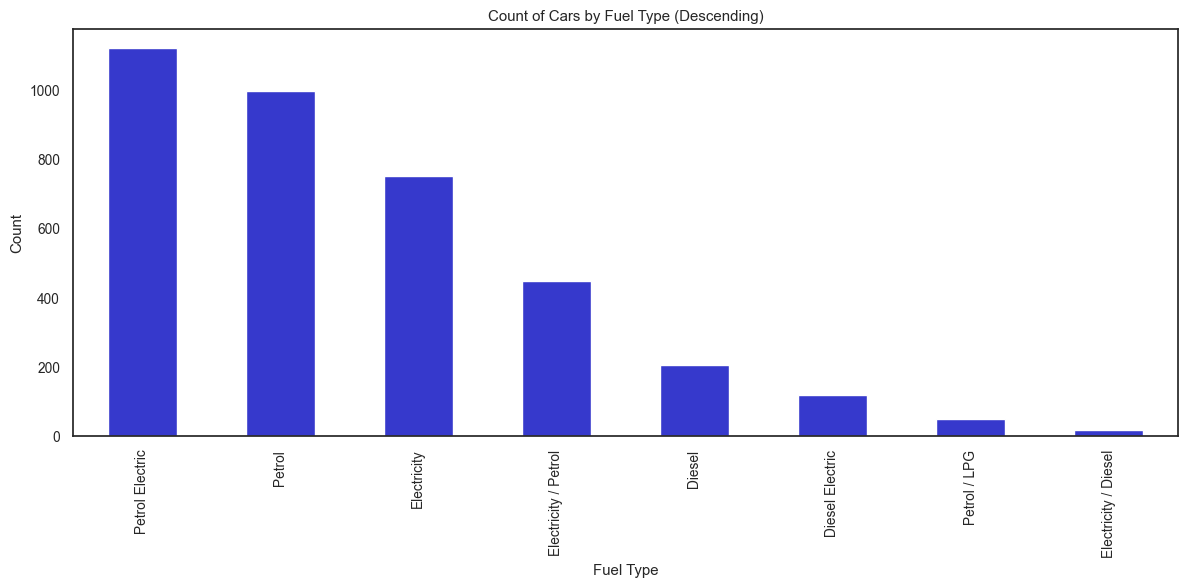

In [880]:
# Plot the categorical data from fuel  type column
fuel_type_counts = data["Fuel Type"].value_counts().reindex(fuel_type_categories, fill_value=0)
sorted_counts = fuel_type_counts.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_counts.plot(kind="bar", color="#3639CC")
plt.title("Count of Cars by Fuel Type (Descending)")
plt.ylabel("Count")
plt.xlabel("Fuel Type")
plt.tight_layout()
plt.show()

## Emissions Analysis
As the discussion is about emission, we will further understand the different types of emissions such as Carbon Monoxide (CO), Carbon Dioxide (CO2), Nitrogen Oxides (NOx) and Total Hydrocarbons (THC). These emissions are not polluting the environment but impacting our health. According to WHO (2021), when CO binds with haemoglobin more readily than oxyegen, it might reduce oxygen transport in blood and posing serious health risks to humans. While CO2 is non-toxis to humans but it significantly contributes to global warming and climate change as it can trap the heat in the atmosphere (Intergovernmental Panel on Climate Change [IPCC], 2021). When the temperature increase, it might bring disasters to human such as flood or extreme heat wave.

### Carbon Monoxide (CO) and Carbon Dioxide (CO2)
From the following bar chart, we can clearly see the emissions of CO2 and CO are co-exists in petrol or hybrid vehicles but not in electric car. Emission of CO is high especially in diesel vehicle and emission of CO2 based on WLTP CO2 is about the same in petrol or diesel verhicles but low in hybrid vehicles. WLTP CO2 Weighted seems to be not reliable as it is empty for most of the vehicles type. 

In [881]:
# Calculate mean emissions by fuel type
metrics_CO2 = ["WLTP CO2", "WLTP CO2 Weighted", "Emissions CO [mg/km]"]
CO2_emission_means = data.groupby("Fuel Type")[metrics_CO2].mean().reindex(fuel_type_categories)

metrics_NOx = ["Emissions NOx [mg/km]", "RDE NOx Urban", "RDE NOx Combined"]
NOx_emission_means = data.groupby("Fuel Type")[metrics_NOx].mean().reindex(fuel_type_categories)

metrics_THC = ["THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]"]
has_thc = all(col in data.columns for col in metrics_THC)
THC_emission_means = (
    data.groupby("Fuel Type")[metrics_THC].mean().reindex(fuel_type_categories)
    if has_thc else None
)


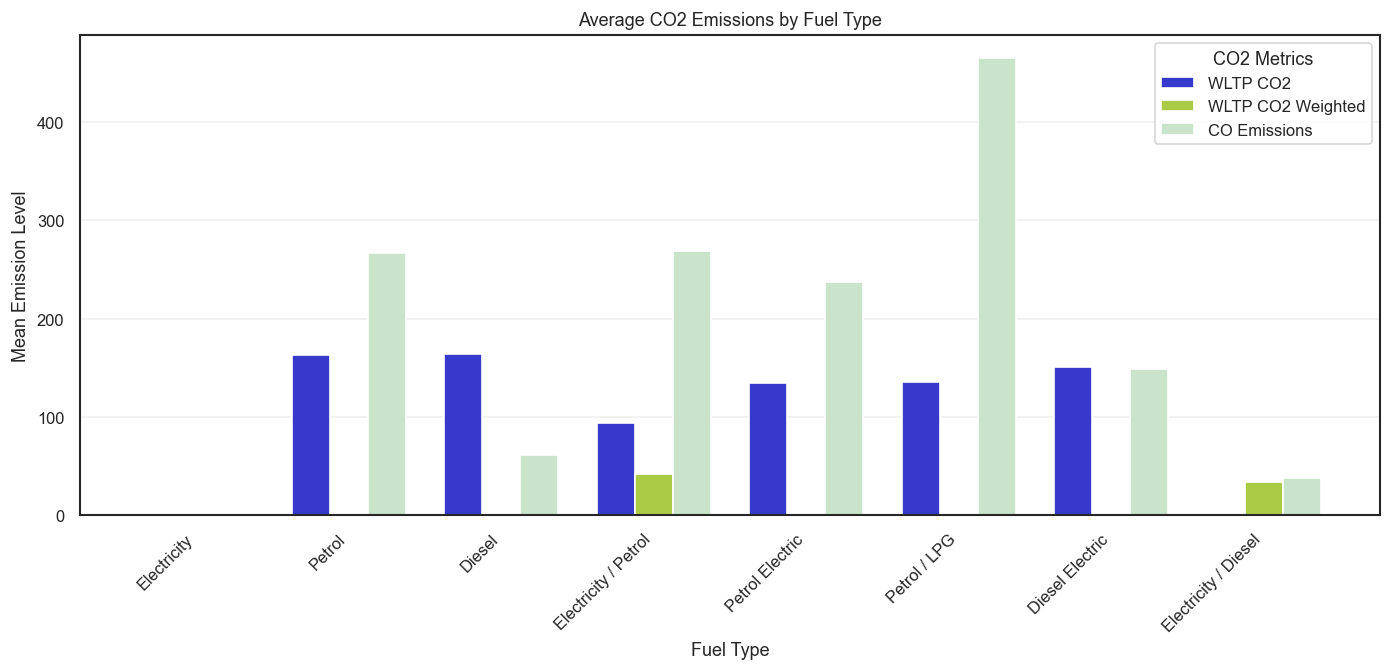

In [882]:
# Plot average CO2 emissions by fuel type
x = np.arange(len(CO2_emission_means.index))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(x - width, CO2_emission_means["WLTP CO2"], width, label="WLTP CO2", color="#3639CC")
ax.bar(x, CO2_emission_means["WLTP CO2 Weighted"], width, label="WLTP CO2 Weighted", color="#ABCA45")
ax.bar(x + width, CO2_emission_means["Emissions CO [mg/km]"], width, label="CO Emissions", color="#C9E4CA")
ax.set_title("Average CO2 Emissions by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Mean Emission Level")
ax.set_xticks(x)
ax.set_xticklabels(CO2_emission_means.index, rotation=45, ha="right")
ax.legend(title="CO2 Metrics")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(pad=2.0)
plt.show()


### Nitrogen Oxides (NOx)
Nitrogen Oxides (NOx) emissions are a major cause to photochemical smog, acid rain, and respiratory health issues (U.S. Environmental Protection Agency [EPA], 2023). Based on following chart, we find NOx emission exists in all the vehicles including electic car. Electric cars do produce a small average amount of NOx according Veza et al (2023). However, it should be understood that the NOx production from electric vehicles is caused from the source of electric used to charge the car batteries. NOₓ emissions from electric vehicles originate from the fossil fuel–based electricity used to charge them. The mean for NOx in Real Driving Emissions (RDE) for urban and combined are about same but they are higher than Emissions (NOx) [mg/km] which was the result tested in lab. 

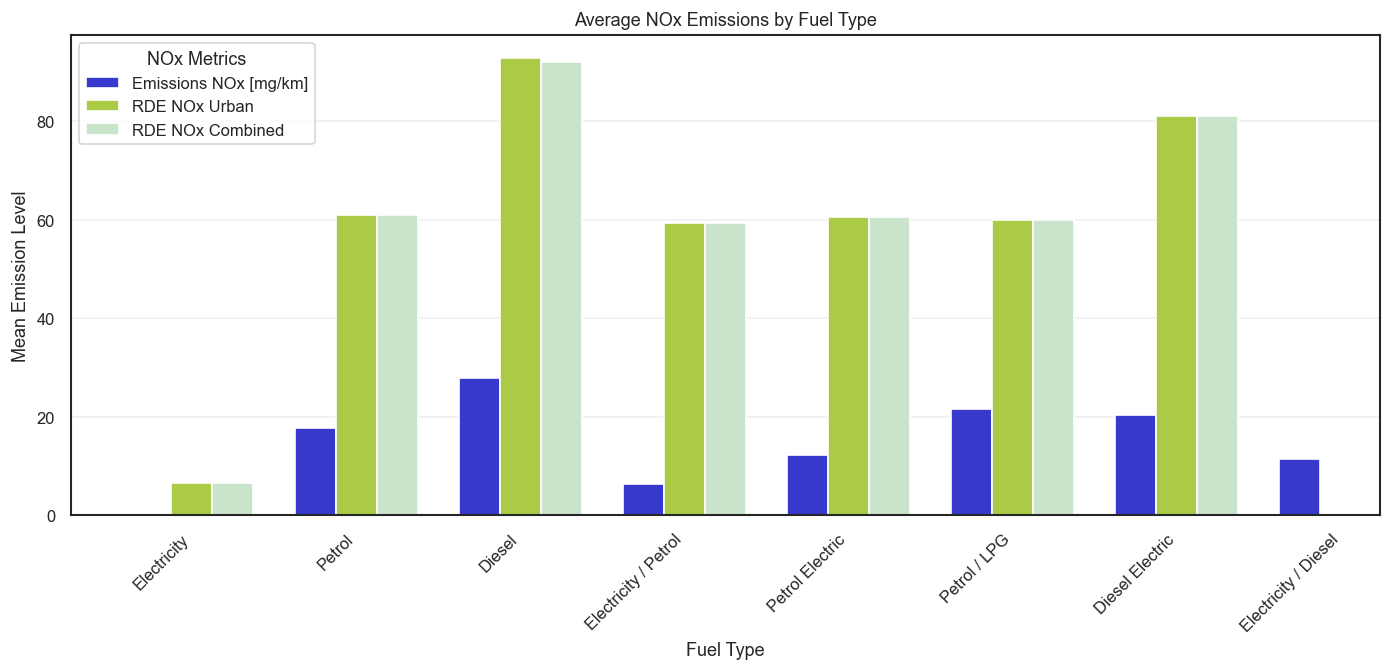

In [883]:
# Plot average NOx emissions by fuel type
x = np.arange(len(NOx_emission_means.index))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(x - width, NOx_emission_means["Emissions NOx [mg/km]"], width, label="Emissions NOx [mg/km]", color="#3639CC")
ax.bar(x, NOx_emission_means["RDE NOx Urban"], width, label="RDE NOx Urban", color="#ABCA45")
ax.bar(x + width, NOx_emission_means["RDE NOx Combined"], width, label="RDE NOx Combined", color="#C9E4CA")
ax.set_title("Average NOx Emissions by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Mean Emission Level")
ax.set_xticks(x)
ax.set_xticklabels(NOx_emission_means.index, rotation=45, ha="right")
ax.legend(title="NOx Metrics")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(pad=2.0)
plt.show()


### Total Hydrocarbons (THC)
Total Hydrocarbons (THC) are volatile organic compounds (VOCs) that react with NOx in the presence of sunlight to form ground-level ozone and smog (European Environment Agency [EEA], 2022). THC might cause photochemical pollution and impact the urban air quality but it have to react with NOx, hence, in this report we will not focus in analysing the relationship of THC with other features.

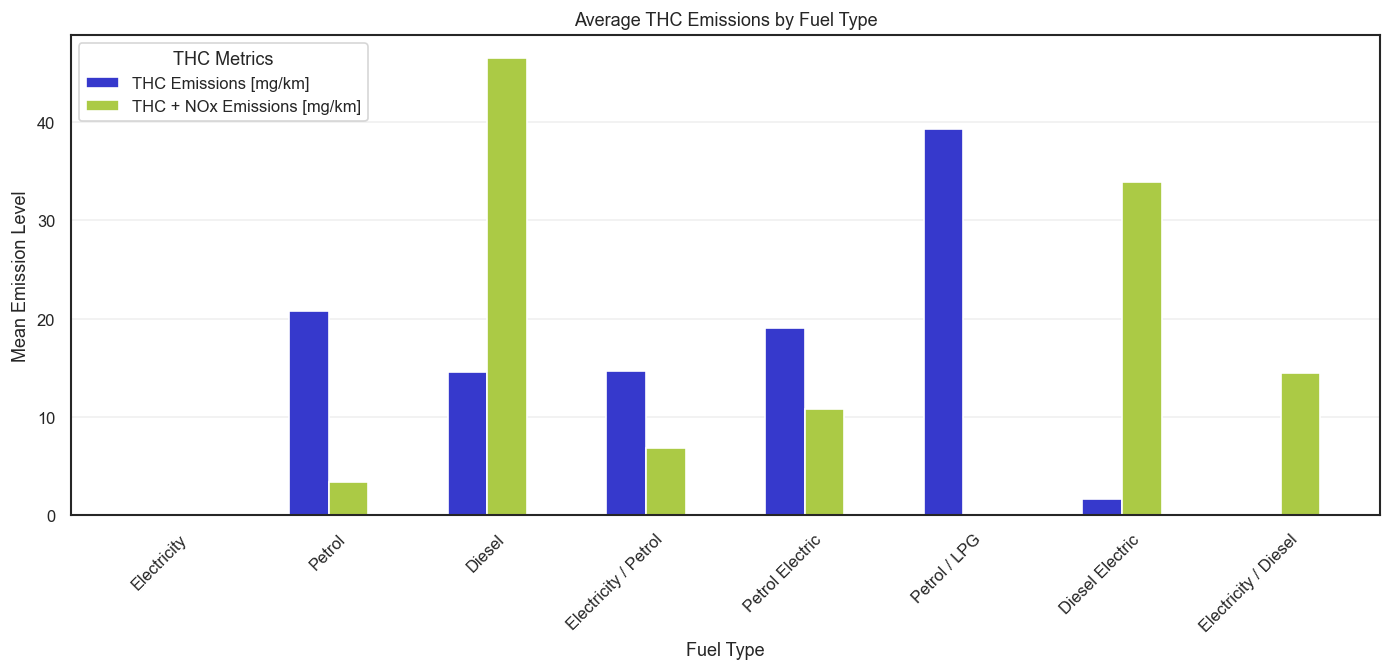

In [884]:
# Plot average THC emissions by fuel type (if available)
if not has_thc or THC_emission_means is None:
    print("THC metrics not available for this dataset.")
else:
    x = np.arange(len(THC_emission_means.index))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
    ax.bar(x - width, THC_emission_means["THC Emissions [mg/km]"], width, label="THC Emissions [mg/km]", color="#3639CC")
    ax.bar(x, THC_emission_means["THC + NOx Emissions [mg/km]"], width, label="THC + NOx Emissions [mg/km]", color="#ABCA45")
    ax.set_title("Average THC Emissions by Fuel Type")
    ax.set_xlabel("Fuel Type")
    ax.set_ylabel("Mean Emission Level")
    ax.set_xticks(x)
    ax.set_xticklabels(THC_emission_means.index, rotation=45, ha="right")
    ax.legend(title="THC Metrics")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(pad=2.0)
    plt.show()


## Target Variables
Based on above analysis, we have enough data for modelling accross different fuel types but we will choose CO2 as global warming is most common topic when discussing about the impacts of emission. As mentioned above, WLTP CO2 Weighted is lacking of data distribution accross fuel types, hence it will be excluded from target variables. Besides of CO2, we will pick Emissions NOx [mg/km] as our target variables because it has difference mean across fuld type which is easier for our comparison and prediction afterward in this report. 

Based on the graphs above, eletric cars have no CO2 emissions, and low NOx emissions. Therefore, all of the eletric cars will be excluded from the datasets when we build the model. Given the distribution, two datasets will be created based on their fuel types - fuel cars only (data_fuel), and hybrid cars only (data_hybrid). Furthermore, since the target variables (WLTP CO2 and NO emissions) are not highly included in Eletricity /Diesel Fuel type, they will be removed from the data_hybrid.

# Feature Selection

Based on the visualisation, following variables should be moved since they are not relevant


In [885]:
removed_variables = [
    "Manufacturer", "Model", "Description",
    "Transmission", "Engine Power (Kw)", "Electric energy consumption Miles/kWh",
    "wh/km", "Maximum range (Km)", "Maximum range (Miles)",
    "Euro Standard", "Diesel VED Supplement", "Testing Scheme", 
    "WLTP CO2 Weighted", "Equivalent All Electric Range Miles", "Equivalent All Electric Range KM",
    "Electric Range City Miles", "Electric Range City Km", "Emissions CO [mg/km]",
    "THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]", "Particulates [No.] [mg/km]",
    "RDE NOx Urban", "RDE NOx Combined", "Noise Level dB(A)", 
    "Date of change",
]

data = data.drop(columns=removed_variables)
print(f"Data shape after removing columns: {data.shape}")

Data shape after removing columns: (3702, 19)


In [886]:
# Define fuel type categories for each group
# electric_types = ["Electricity"]

hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric"]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
# data_electric = data[data["Fuel Type"].isin(electric_types)] #Can remove since not relevant to the target variable
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]

# print(f"Electric cars: {data_electric.shape[0]} rows")
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")
# print(f"Original data: {data.shape[0]} rows ") #To check whether the split is correct

Hybrid cars: 1686 rows
Fuel cars: 1250 rows


Dataset shape before removing NA values: (1250, 19)


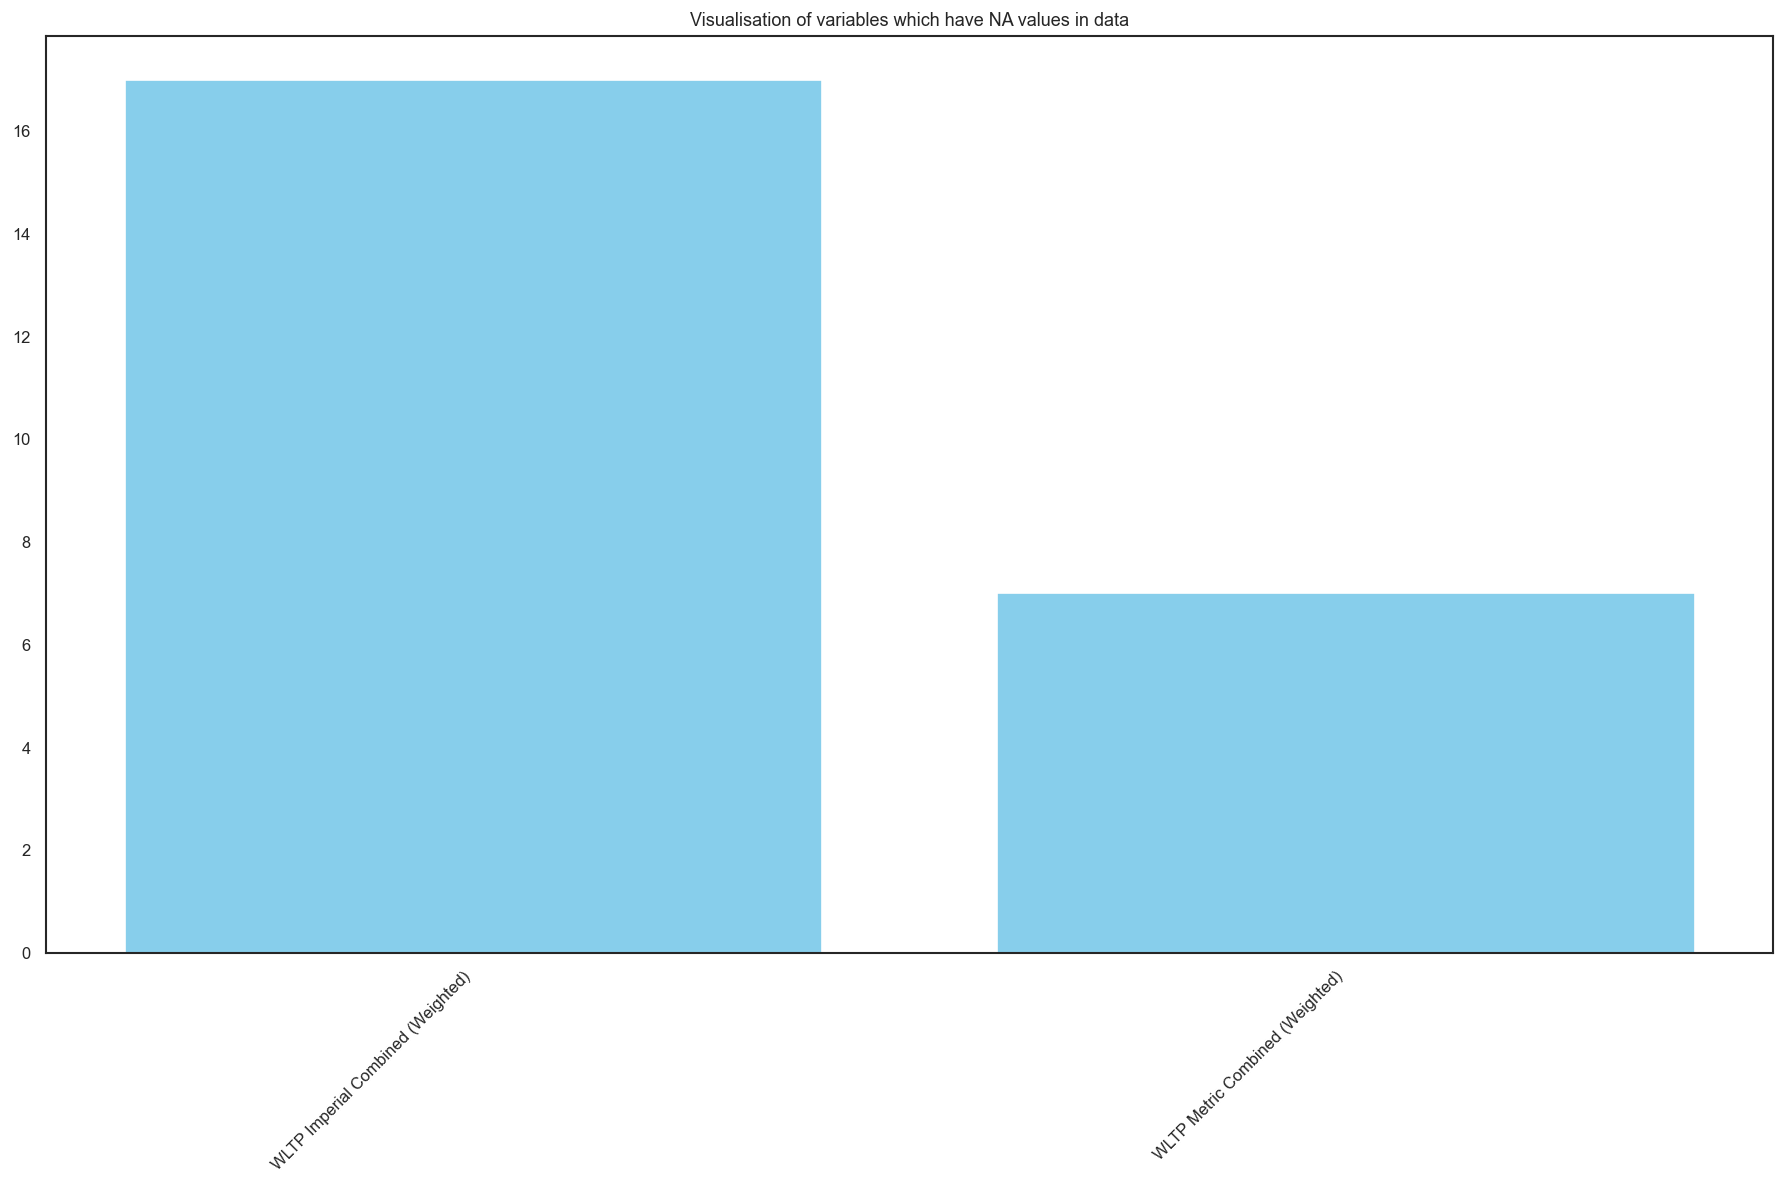

In [887]:
# this function count and visualise any columns that has NA values as bar chart 
def count_visualisa_na(data, data_name = "data"):
    NA_list = []
    col_name_list = []
    for i in range(data.shape[1]):
        col_name = data.columns[i]
        count = data[col_name].isna().sum()
        if count != 0: 
            NA_list.append(count)
            col_name_list.append(col_name)
                
    fig, axs = plt.subplots(1, 1, figsize=(15, 10), dpi=120, sharey=True)
    axs.bar(col_name_list, NA_list, color = "skyblue")
    plt.xticks(rotation = 45, ha = "right")
    plt.title(f'Visualisation of variables which have NA values in {data_name}')
    fig.tight_layout()
    plt.show()
    
#Check and remove NA values in fuel dataset
print("Dataset shape before removing NA values:", data_fuel.shape)
count_visualisa_na(data_fuel)

In [888]:
data_fuel = data_fuel.dropna()
print("Dataset shape after removing NA values:", data_fuel.shape)


Dataset shape after removing NA values: (1233, 19)


Dataset shape before removing NA values: (1686, 19)


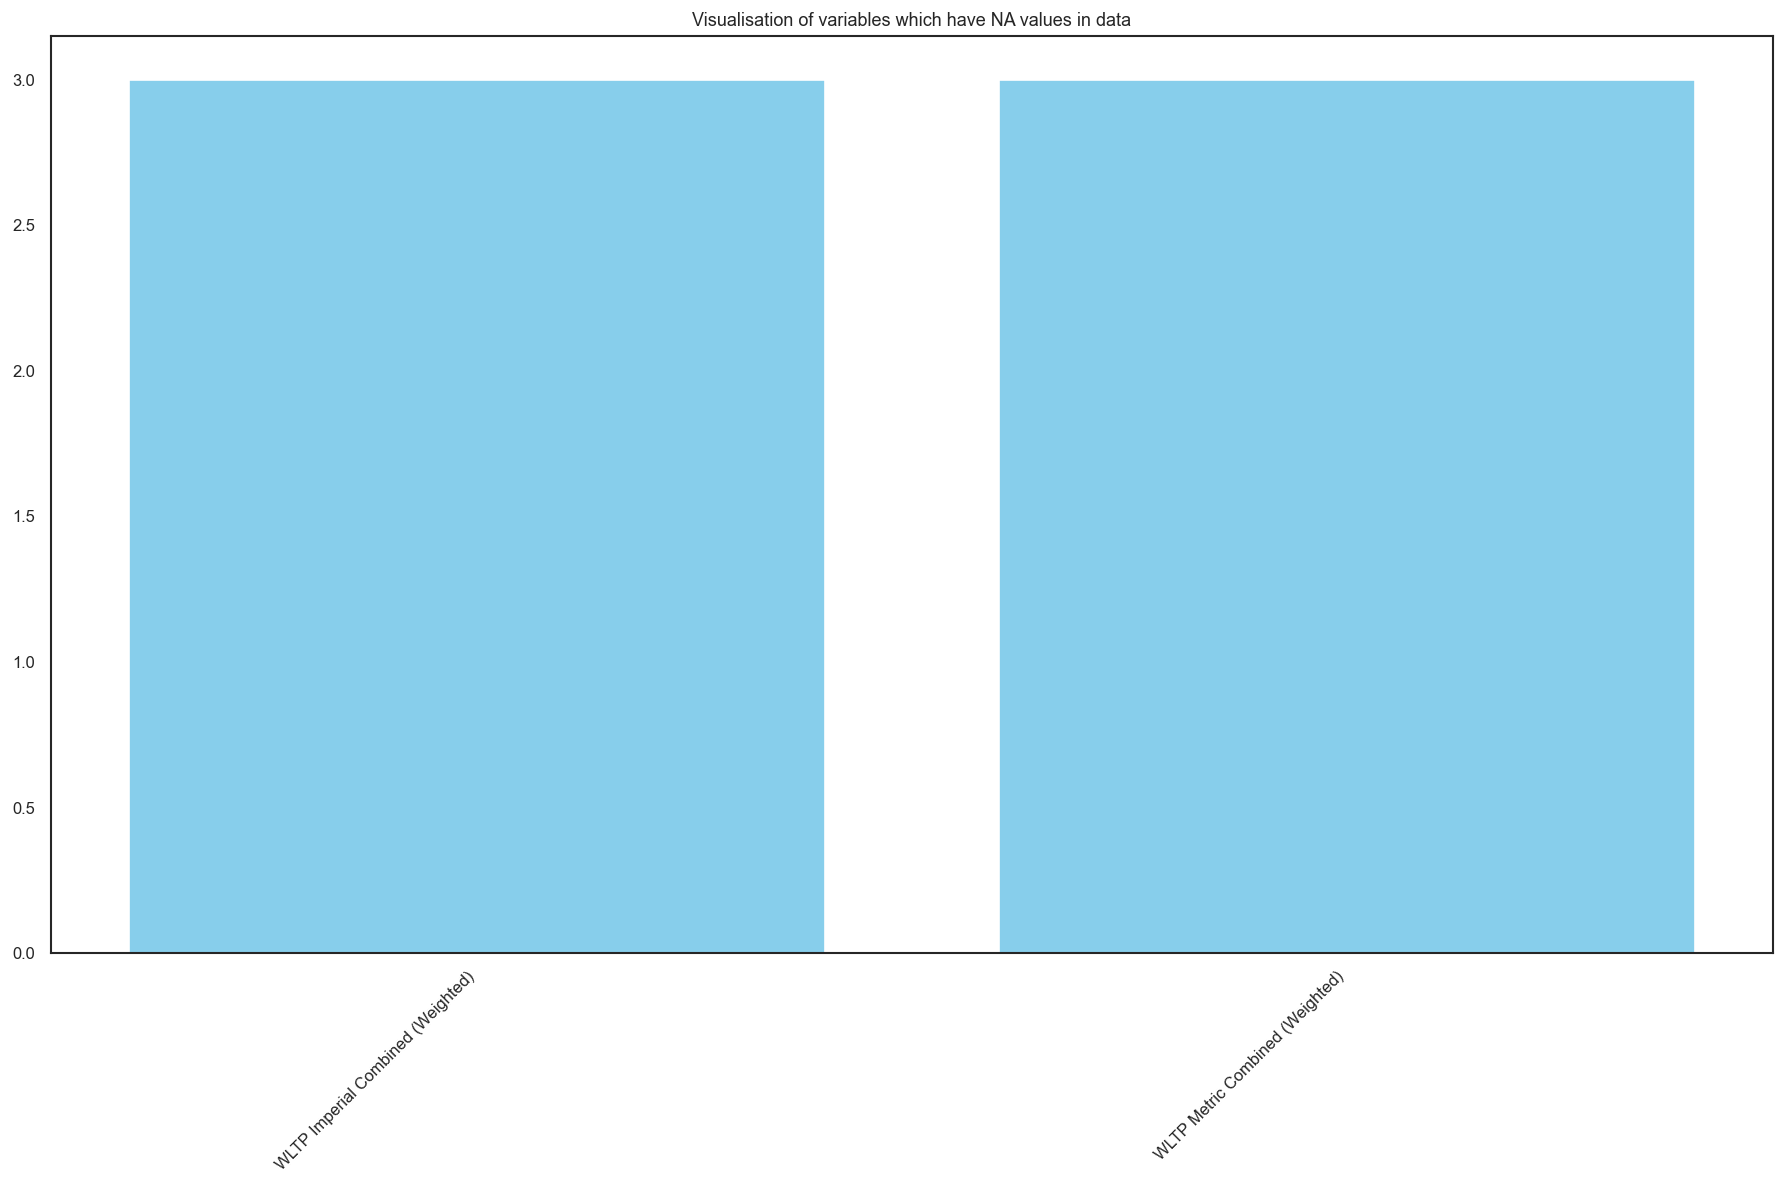

In [889]:
#Check and remove NA values in fuel dataset
print("Dataset shape before removing NA values:", data_hybrid.shape)
count_visualisa_na(data_hybrid)

In [890]:
data_hybrid = data_hybrid.dropna()
print("Dataset shape after removing NA values:", data_hybrid.shape)

Dataset shape after removing NA values: (1683, 19)


### Statistical Analysis

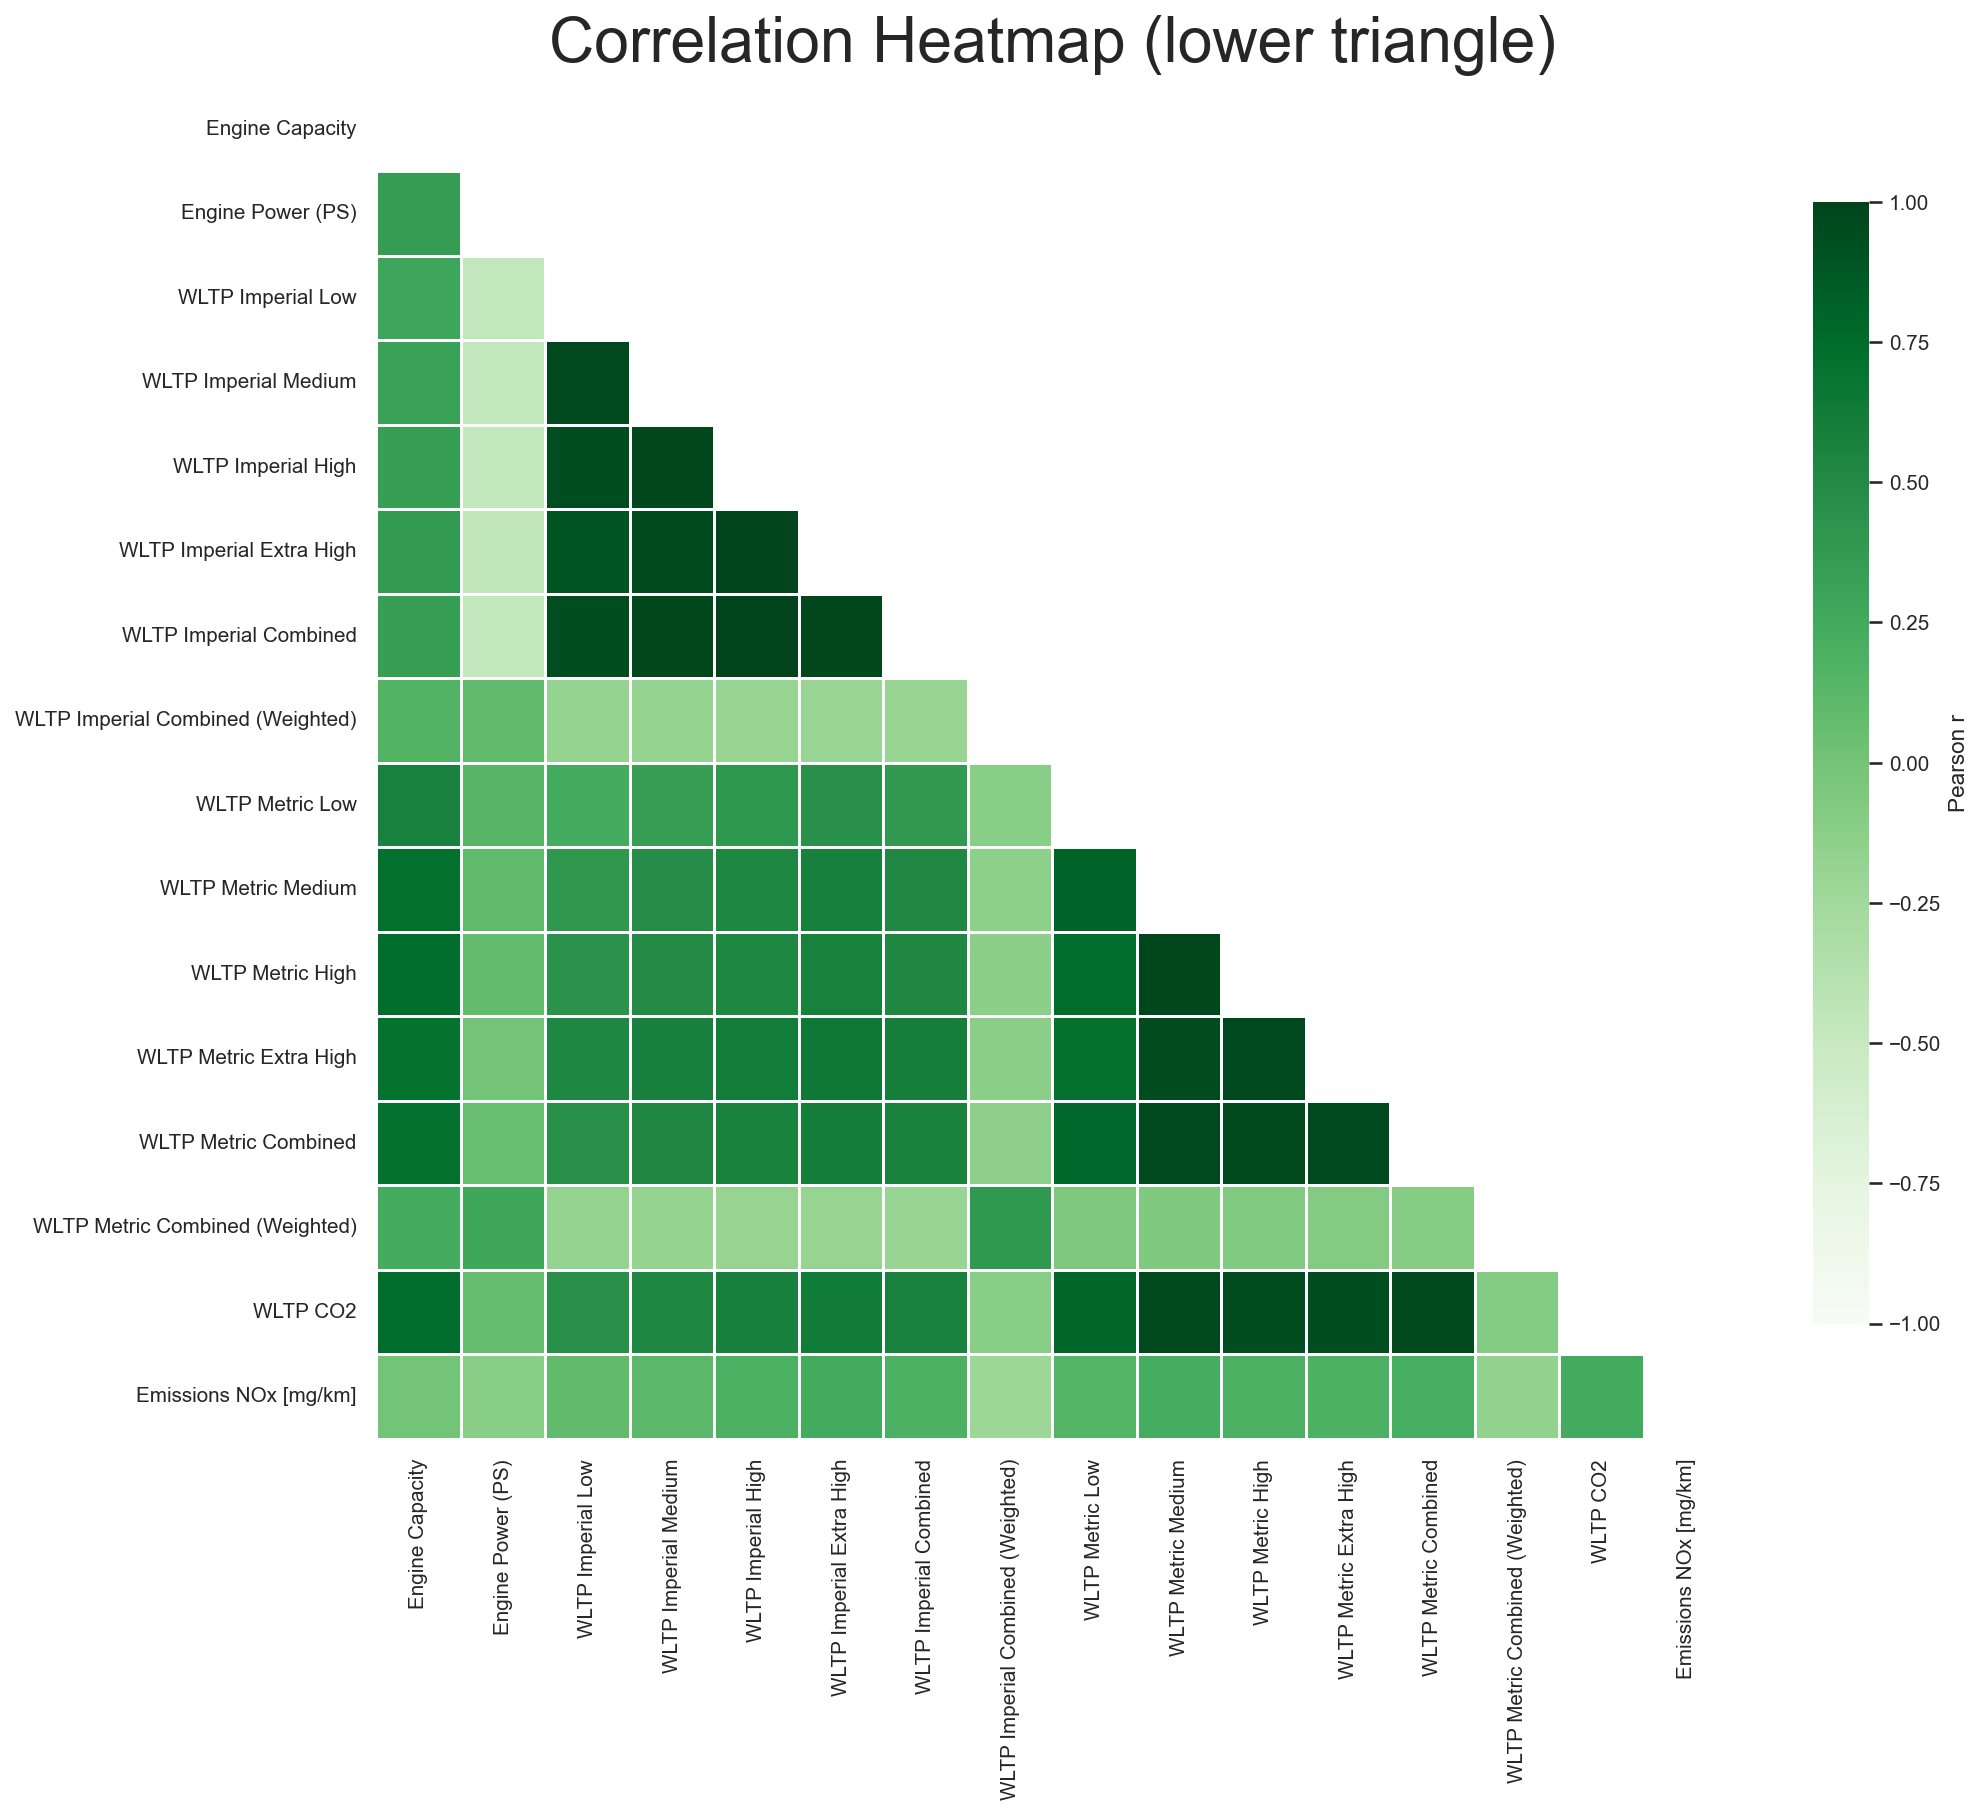

In [891]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", fontsize = 30, pad=12)
plt.tight_layout()
plt.show()

Since it is over detailed to visualise the correlation matrix of all variables, only top 20 will be visualised to examine their correlations.

In [892]:
# Create a function to plot top Correlation values based on the target variable
def plot_top20_correlation(variable:str, data):
    # Set the target variable 
    target = variable

    # numeric-only correlation
    corr = data.select_dtypes(include='number').corr()

    # Extract correlations with target
    target_corr = corr[target].drop(labels=[target])

    # Sort by absolute correlation and take top 20
    top20 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(20)

    # Plot
    plt.figure(figsize=(8, 7), dpi=150)
    bars = plt.barh(top20.index, top20.values, color='seagreen', edgecolor='black')

    # Add correlation values on bars
    for bar, value in zip(bars, top20.values):
        plt.text(value, bar.get_y() + bar.get_height()/2, f"{value:.2f}",
                ha='left' if value > 0 else 'right', va='center', fontsize=9)


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Top 20 Correlations with {target} from {data_label}", fontsize=15, pad=10)
    plt.xlabel("Correlation - Pearson r", fontsize=11)
    plt.ylabel("Variable", fontsize=11)
    plt.gca().invert_yaxis()  # highest correlation on top
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

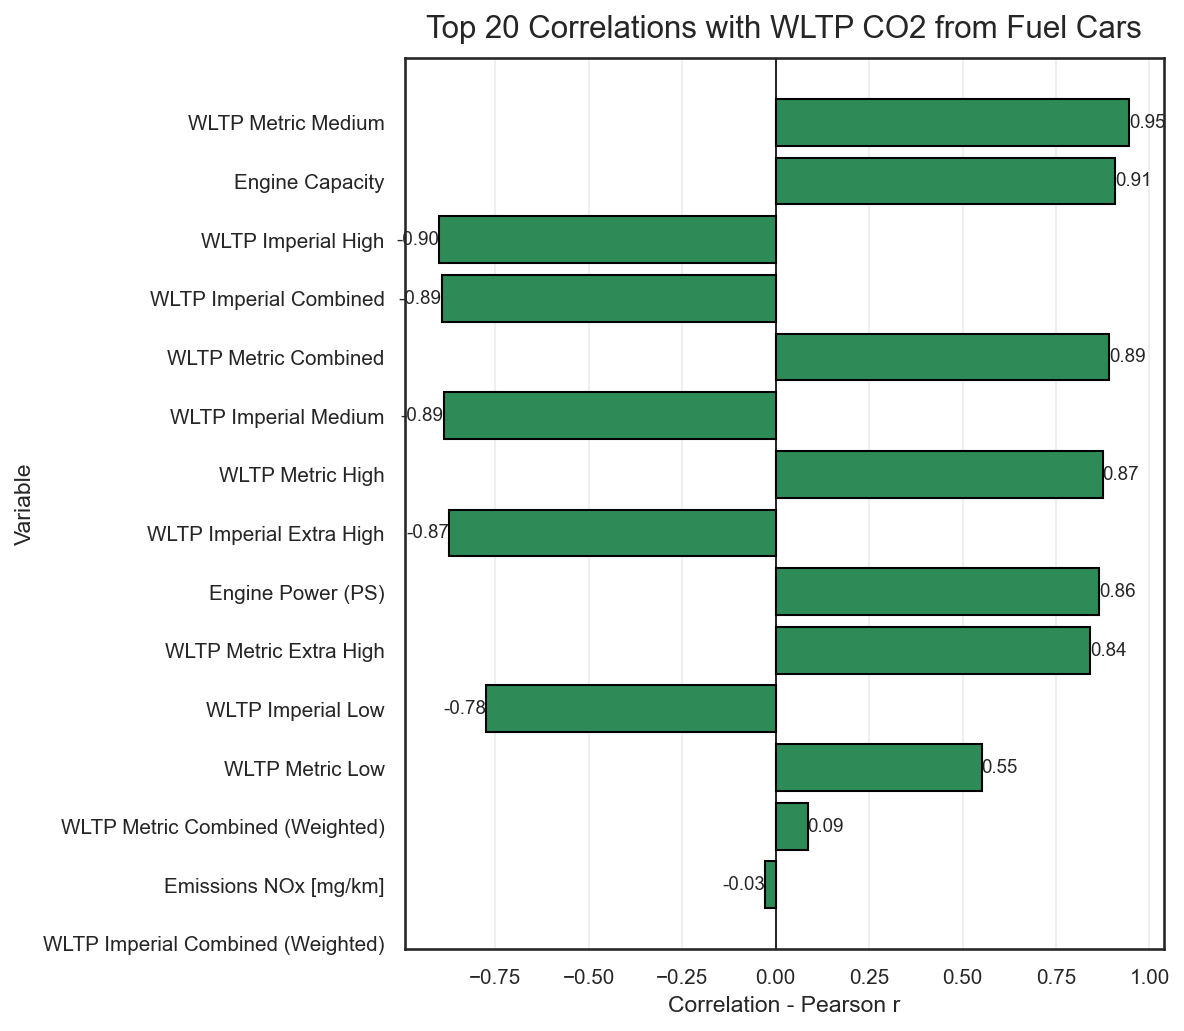

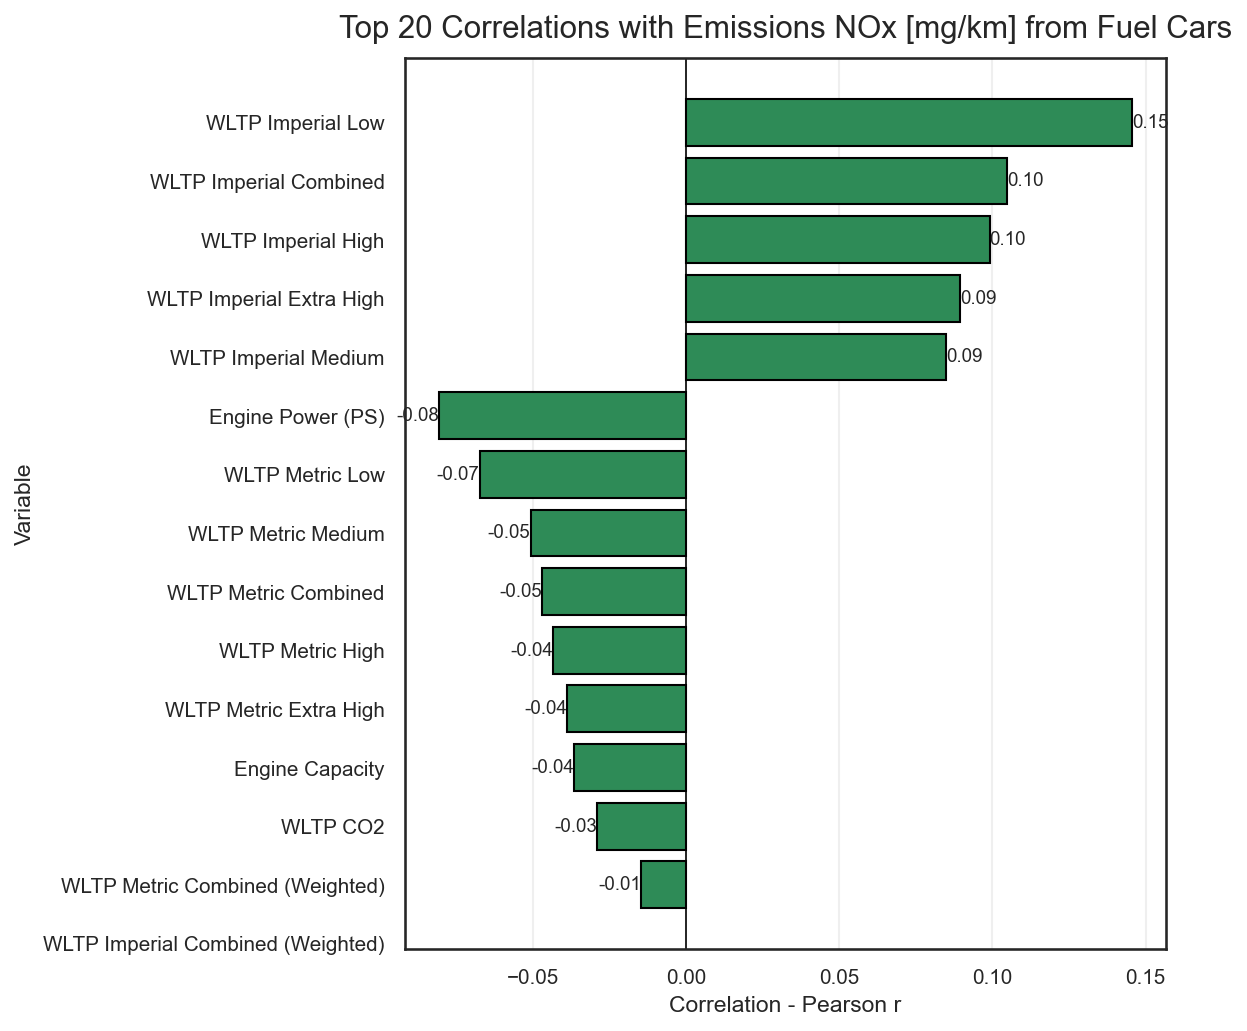

In [893]:
# -- Correlation Matrix for Fuel Cars
plot_top20_correlation("WLTP CO2", data_fuel)
plot_top20_correlation("Emissions NOx [mg/km]", data_fuel)

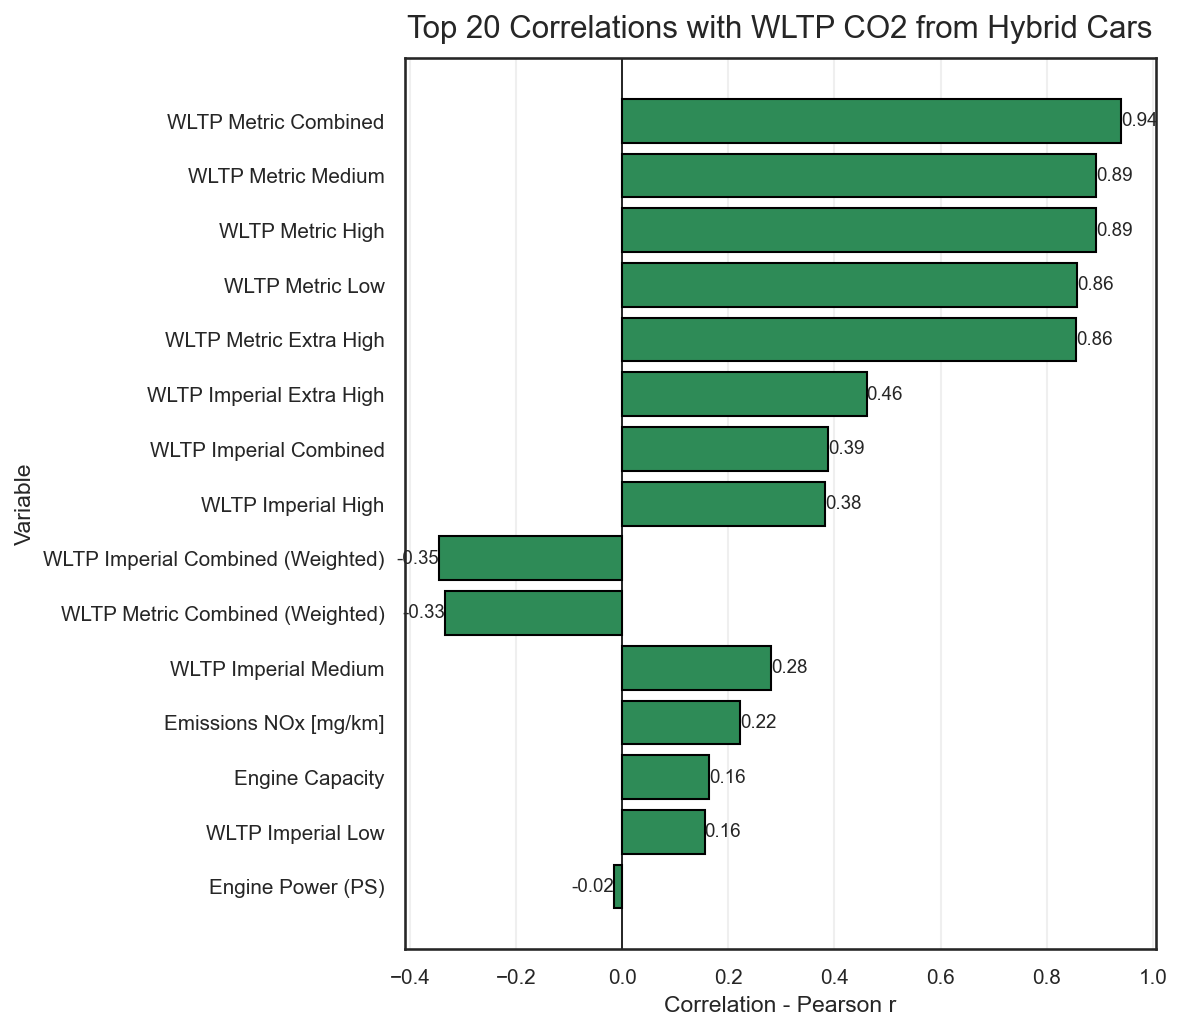

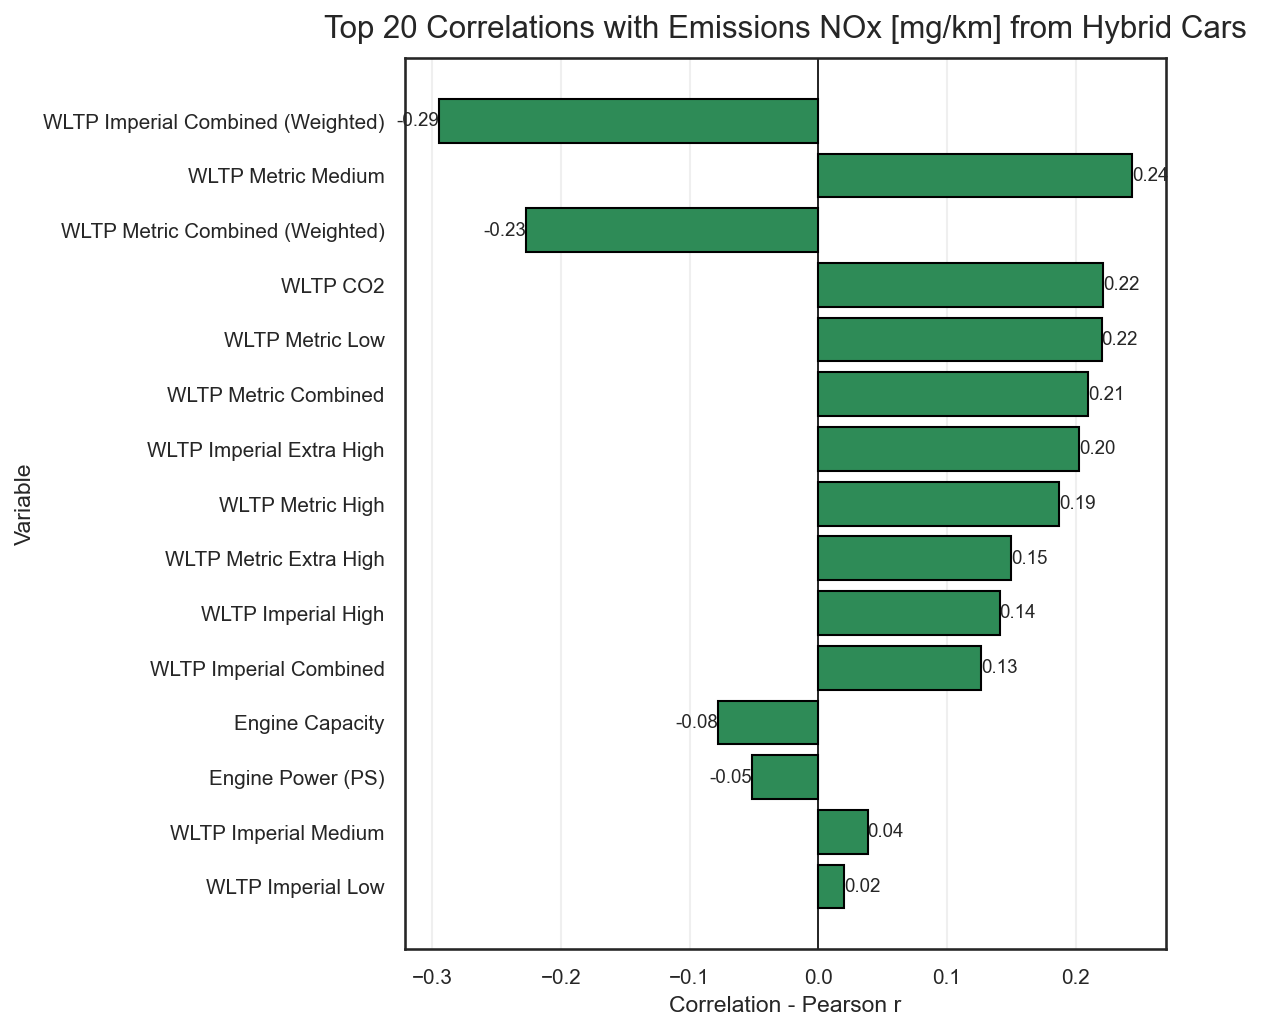

In [894]:
# -- Correlation Matrix for Hybrid Cars
plot_top20_correlation("WLTP CO2", data_hybrid)
plot_top20_correlation("Emissions NOx [mg/km]", data_hybrid)

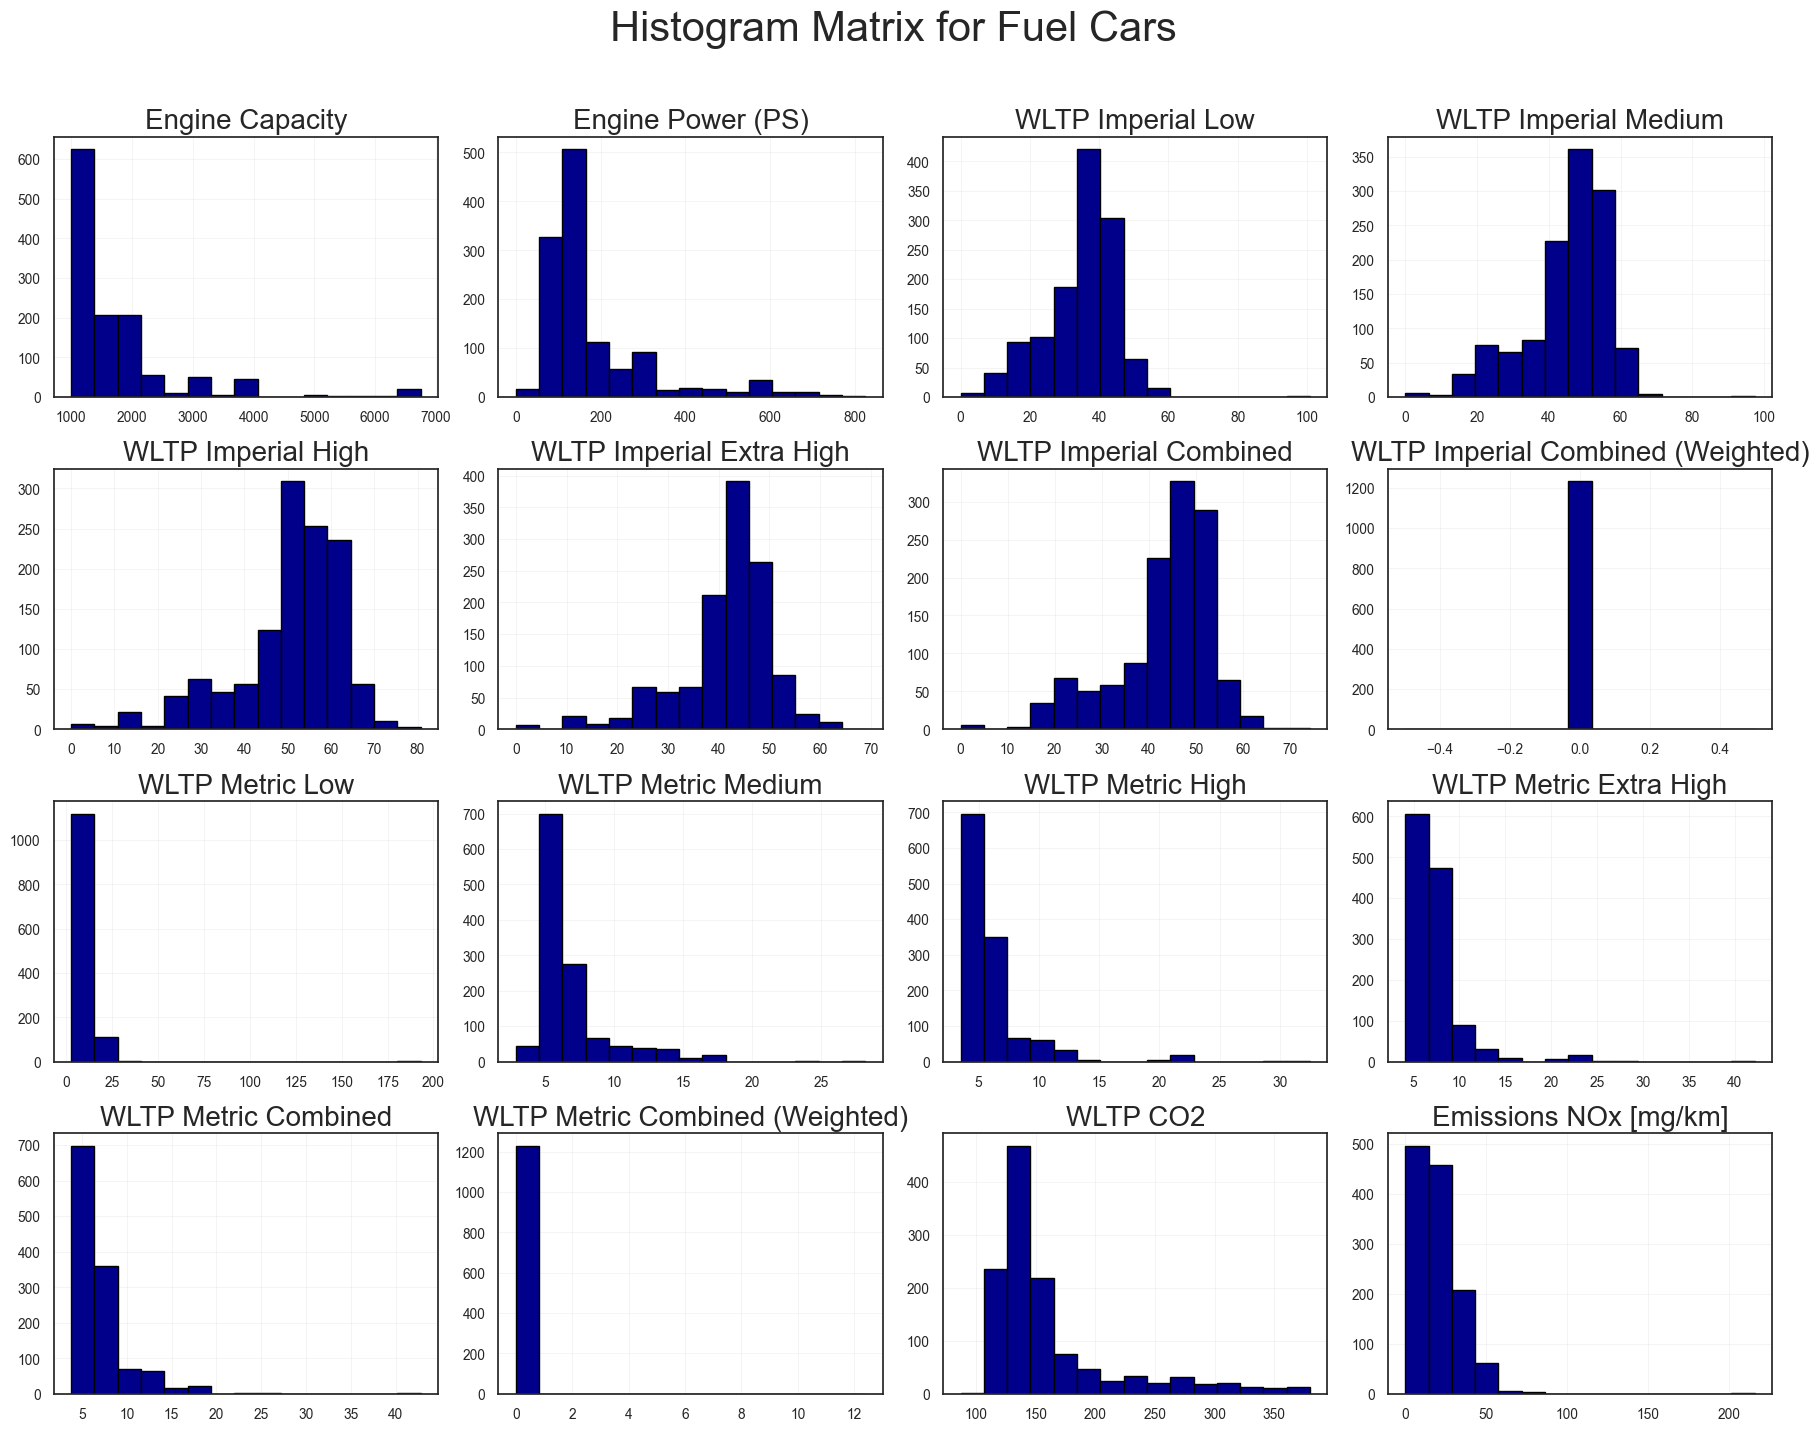

In [895]:
# -- Histogram Matrix for Fuel Cars --

# Set overall figure size (width, height)
axes = data_fuel.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Fuel Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

Remove WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) due to their unsual distribution.

In [896]:
# Remove irrelevant columns for regression task
data_fuel = data_fuel.drop(columns=["WLTP Imperial Combined (Weighted)", "WLTP Metric Combined (Weighted)"])
data_fuel.shape

(1233, 17)

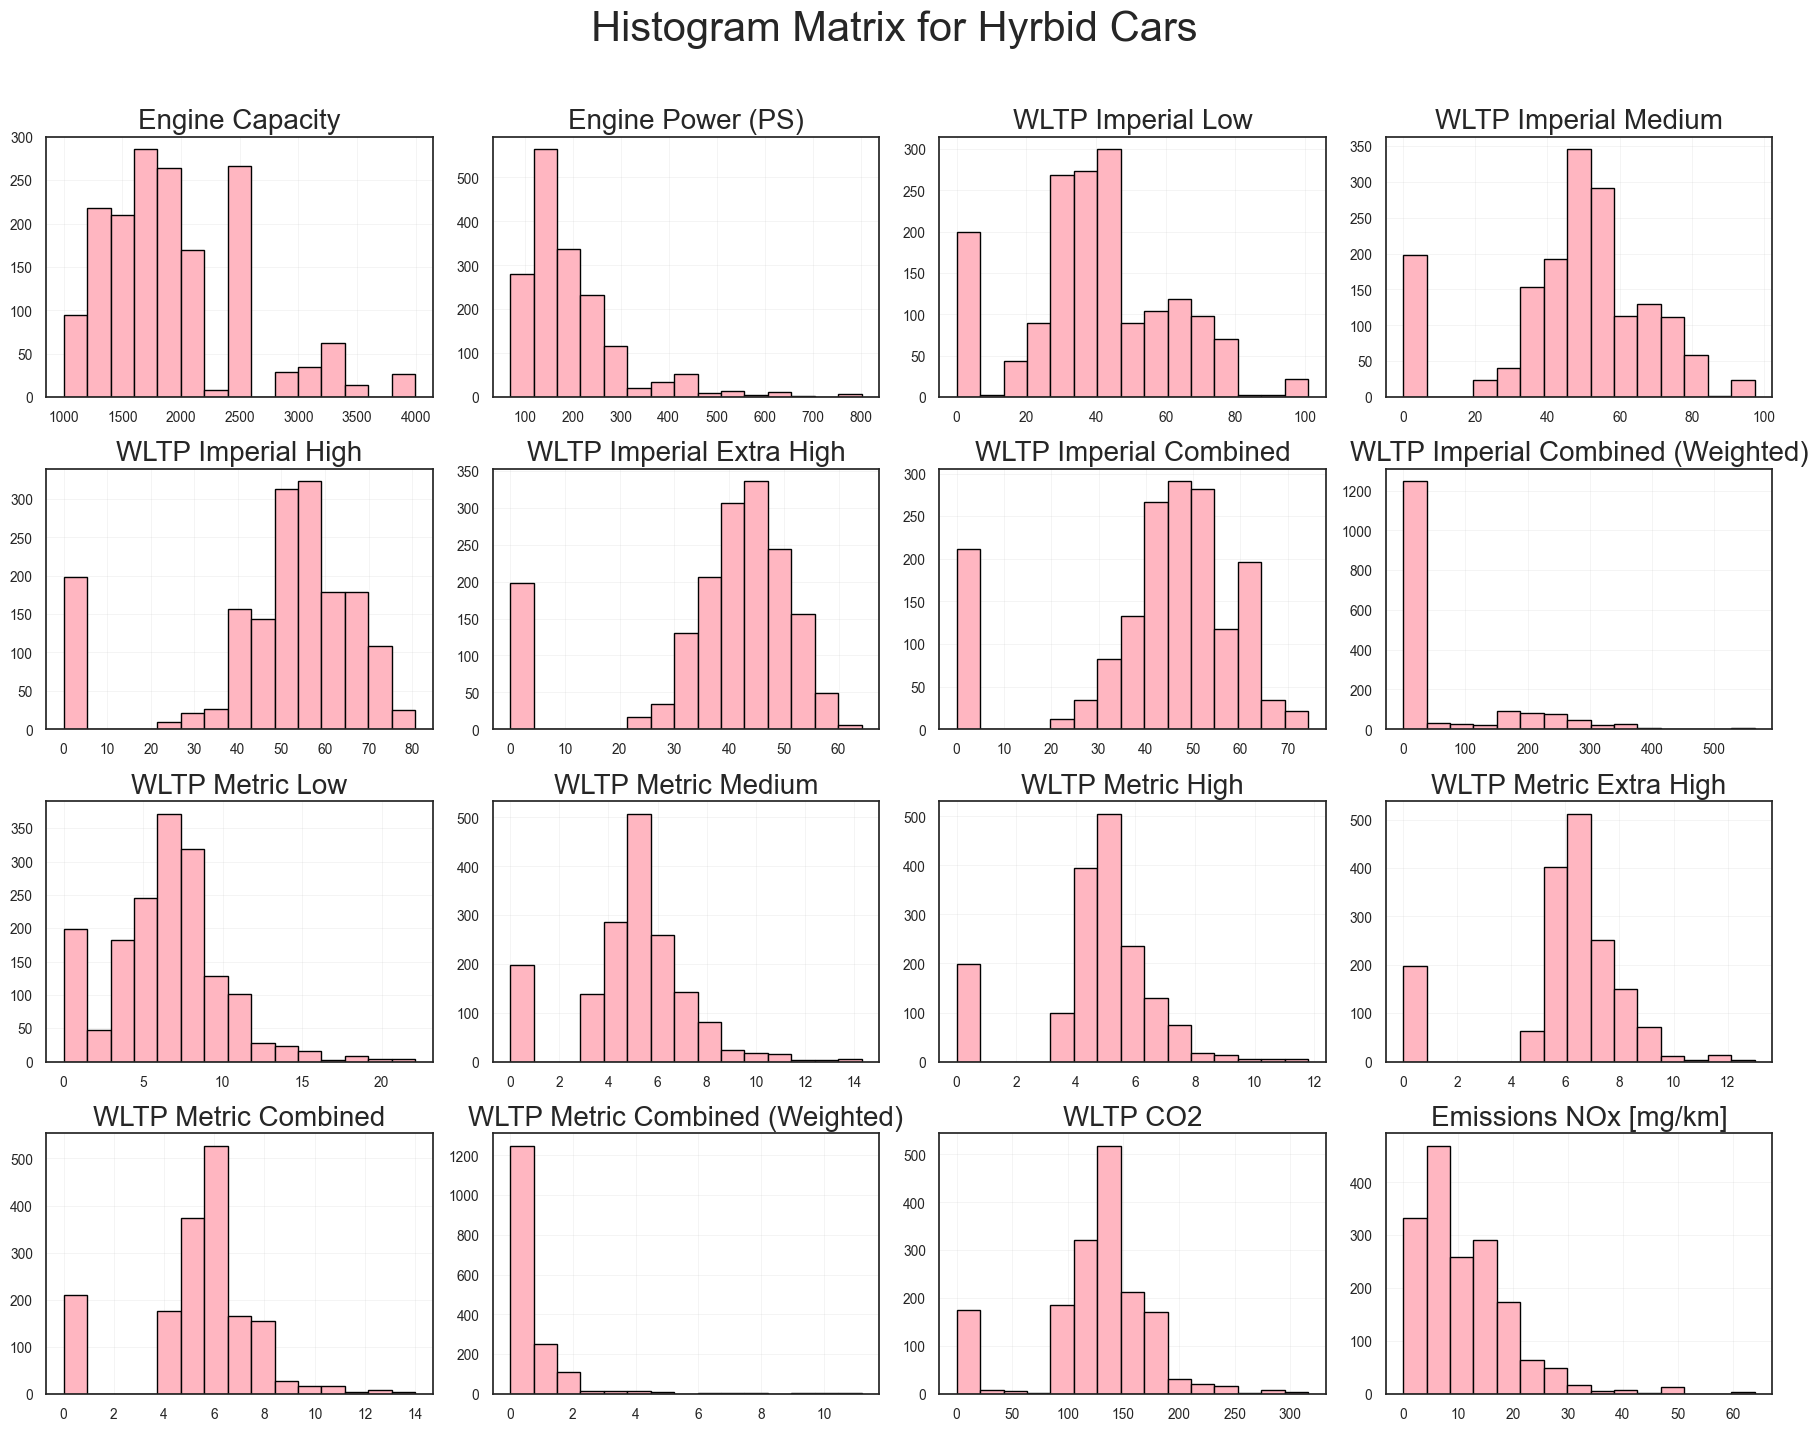

In [897]:
# -- Histogram Matrix for Hyrbid Cars --

# Set overall figure size (width, height)
axes = data_hybrid.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='lightpink',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Hyrbid Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

### Outlier Check

Checking outliers on fuel car dataset

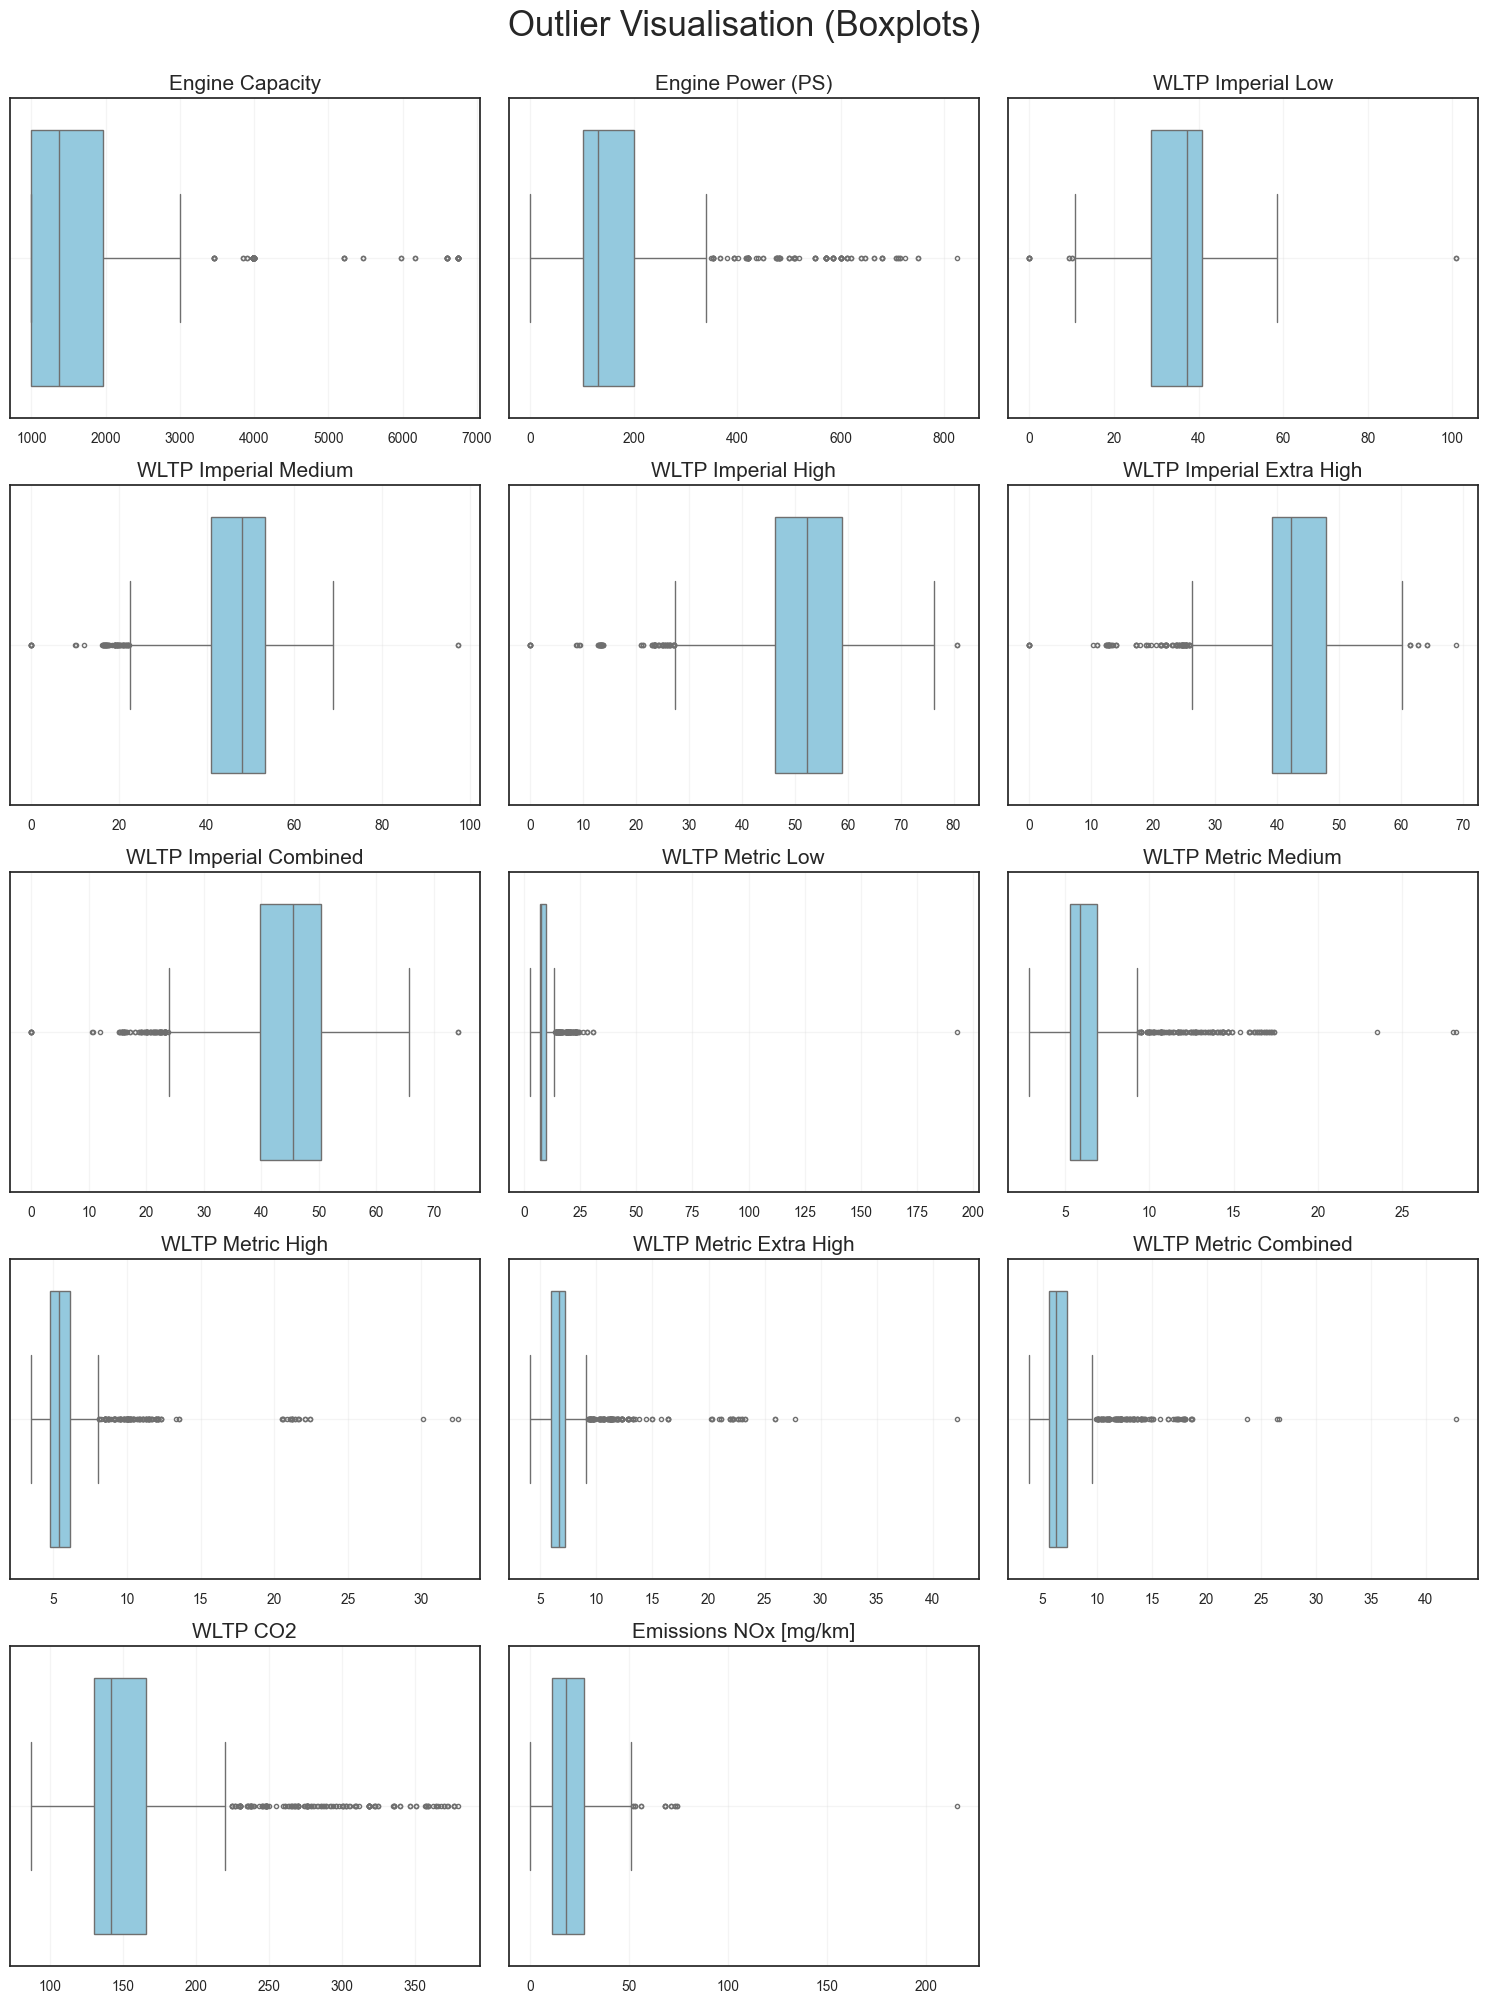

In [898]:
# A reusable function to visualise outliers, arguments: dataset
def outlier_check(data):
    # Select only numeric columns
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric_cols) == 0:
        print("No numeric columns found in the dataset.")
        return
    
    # Determine layout
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    
    # Set up figure
    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    plt.suptitle("Outlier Visualisation (Boxplots)", fontsize=25, y =1)
    
    # Create boxplots for each numeric column
    for idx, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, idx)
        sns.boxplot(x=data[col], color='skyblue', fliersize=3, linewidth=1)
        plt.title(col, fontsize=15)
        plt.xlabel("")
        plt.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

outlier_check(data_fuel)

The following variables should be removed from fuel car data since they have high amount of outliers: 

In [899]:
removed_variables_fuel = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined" ]

print(f"Data shape before removing columns: {data_fuel.shape}")

data_fuel = data_fuel.drop(columns=removed_variables_fuel)
print(f"Data shape after removing columns: {data_fuel.shape}")

Data shape before removing columns: (1233, 17)
Data shape after removing columns: (1233, 12)


Checking outliers on hybrid car dataset

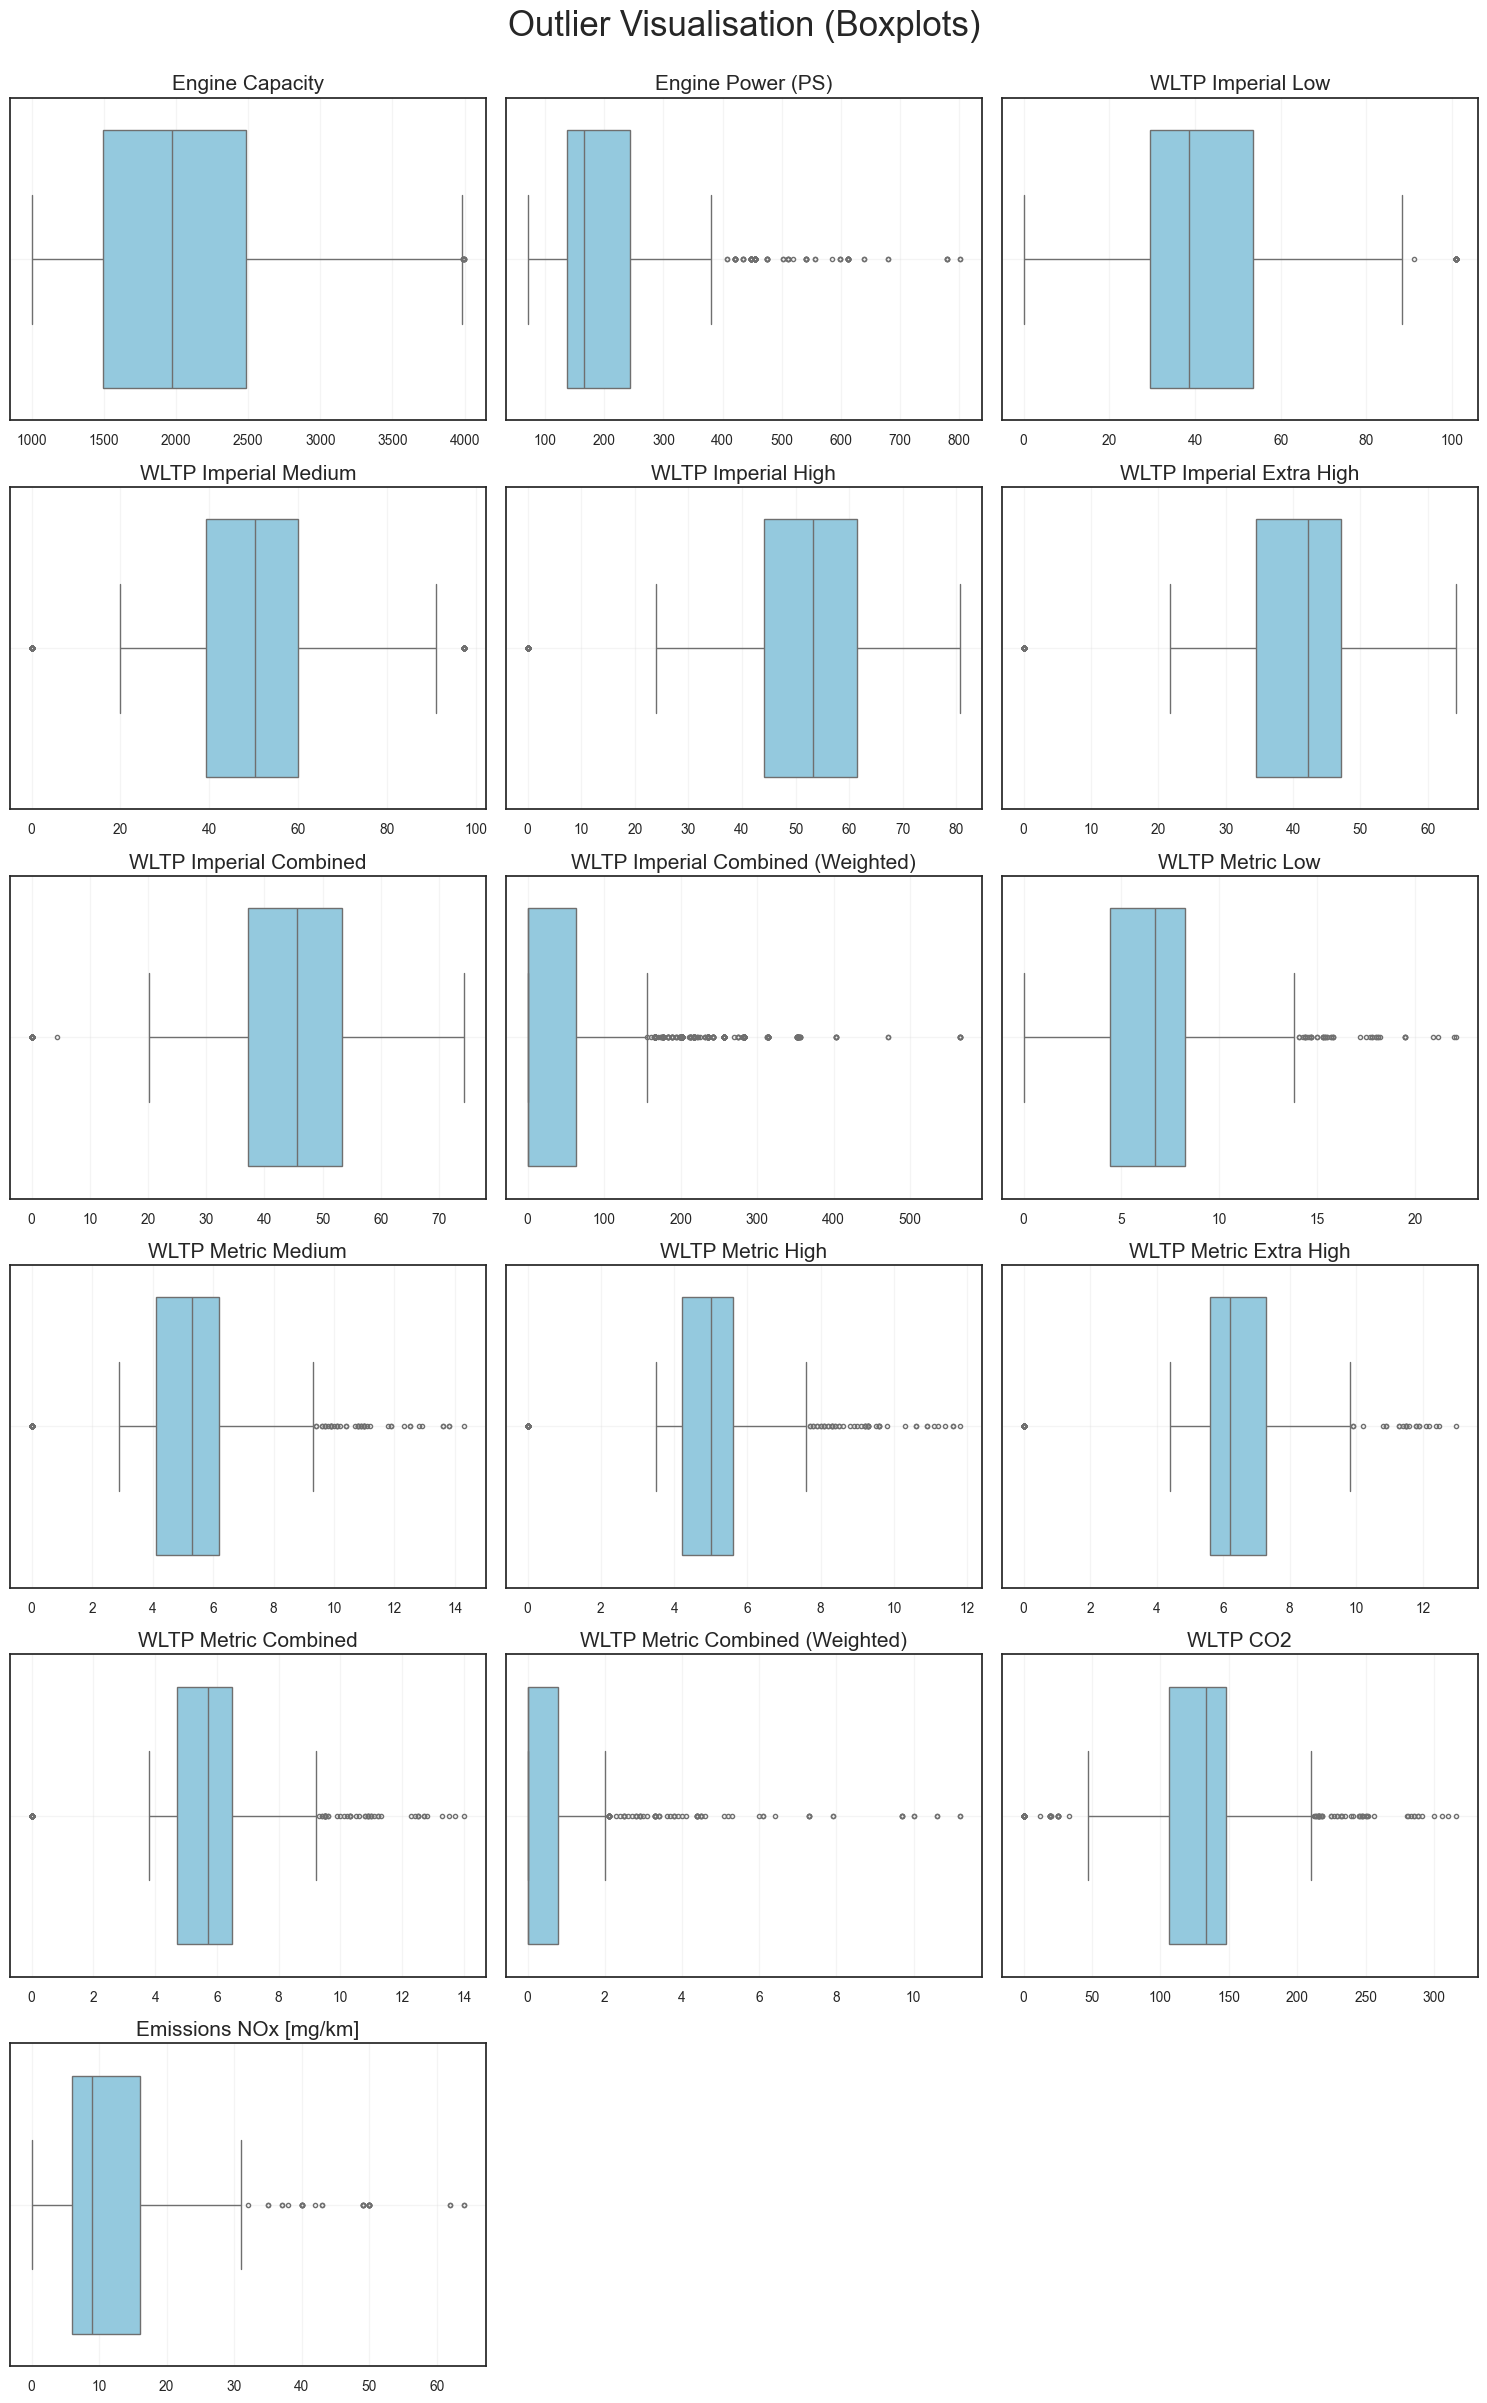

In [900]:
outlier_check(data_hybrid)

The following variables should be removed from fuel car data since they have high amount of outliers: 

In [901]:
removed_variables_hybrid = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined", "WLTP Metric Combined (Weighted)",
                            "WLTP Imperial Combined (Weighted)" ]

print(f"Data shape before removing columns: {data_hybrid.shape}")

data_hybrid = data_hybrid.drop(columns=removed_variables_hybrid)
print(f"Data shape after removing columns: {data_hybrid.shape}")

Data shape before removing columns: (1683, 19)
Data shape after removing columns: (1683, 12)


Decide which variables to be removed for hybrid cars (comment here)

### The validation of datasets

In [902]:
# Data Splitting Function into training set, test set, and validation set
np.random.seed(42) # for reproducibility

def data_split(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."
    
    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]
    
    # Simple numeric imputation (if there are any remaining NaNs)
    # X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    
    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                         random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                     random_state=random_state)
     
    # Encode categorical variables as dummy/one-hot columns
    X_train = pd.get_dummies(X_train, drop_first=True, dtype=float)
    X_val   = pd.get_dummies(X_val,   drop_first=True, dtype=float)
    X_test  = pd.get_dummies(X_test,  drop_first=True, dtype=float)

    #Re-index columns after encoding
    train_cols = X_train.columns
    X_val  = X_val.reindex(columns=train_cols, fill_value=0)
    X_test = X_test.reindex(columns=train_cols, fill_value=0)
    
    #Scaling the X data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return {
         "X_train": X_train,
         "X_val": X_val,
         "X_test": X_test,
         "y_train": y_train,
         "y_val": y_val,
         "y_test": y_test
    }     

#reuse this part to access the splitted data.
splits = data_split("WLTP CO2", data_fuel)

# Access the data 
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(X_train[0:5,:])

(986, 13)
(124, 13)
(123, 13)
[[-0.69355105 -0.66468299  0.23878138  0.22261852  0.16192353  0.0135079
   0.15199583 -1.26703709 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [ 3.44051473  3.98740879 -2.37420157 -2.1867223  -2.14748521 -2.05174708
  -2.26179734  0.2015991   1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69355105 -0.50040367  0.59553551  0.43249142  0.31956235  0.087267
   0.29071957 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.20296869 -0.23158296 -0.03119472 -0.14675777 -0.18488188 -0.16562136
  -0.08845866 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69453418 -0.81402783  1.51152584  1.47346097  1.34421469  0.86700613
   1.23404104 -0.62849962 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]]


*Fuel car data*


In [903]:
# -- Reusable function for 10-fold CV and evaluation (regression task)--

np.random.seed(42) # for reproducibility

def tenfold_dataValidation(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    #reuse this part to access the splitted data.
    splits = data_split(target, data)

    # Access the data 
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    linear_model = LinearRegression()

    # 10-fold CV on TRAIN ONLY (neg MSE -> MSE) 
    mse_scores = -cross_val_score(linear_model, X_train, y_train, cv=10,
                              scoring="neg_mean_squared_error")
    
    print("10-fold CV MSE scores:", mse_scores.tolist())
    print("Mean MSE:", np.mean(mse_scores))

    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    # --- Plot CV MSE ---
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-')
    plt.title(f'10-Fold Cross-Validation (MSE) of {target} from {data_label}')
    plt.xlabel('Fold Number'); plt.ylabel('Mean Squared Error (MSE)')
    plt.grid(alpha=0.3); plt.xticks(range(1, 11))

    # --- Fit on train, check validation ---
    linear_model.fit(X_train, y_train)
    val_pred  = linear_model.predict(X_val)
    test_pred = linear_model.predict(X_test)

    # MSE on validation and test
    print("Validation MSE:", mean_squared_error(y_val,  val_pred))
    print("Test MSE:",       mean_squared_error(y_test, test_pred))
    print("\n") #spacing for readability

    # RMSE on validation and test
    print("Validation RMSE:", np.sqrt(mean_squared_error(y_val,  val_pred)))
    print("Test RMSE:",  np.sqrt(mean_squared_error(y_test, test_pred))) 

    # return splitted datasets for further use in NN function
    # return {
    # "X_train": X_train,
    # "X_val": X_val,
    # "X_test": X_test,
    # "y_train": y_train,
    # "y_val": y_val,
    # "y_test": y_test
    # }

10-fold CV MSE scores: [226.8818560077228, 71.07971037711793, 240.4021221495773, 228.03641940795396, 185.59233512324136, 201.05651444852853, 392.8378576500156, 127.07826439321468, 237.20072334626278, 203.96008070823763]
Mean MSE: 211.41258836118723
Validation MSE: 936.3065519621466
Test MSE: 949.1974967211949


Validation RMSE: 30.599126653585174
Test RMSE: 30.809048942172733


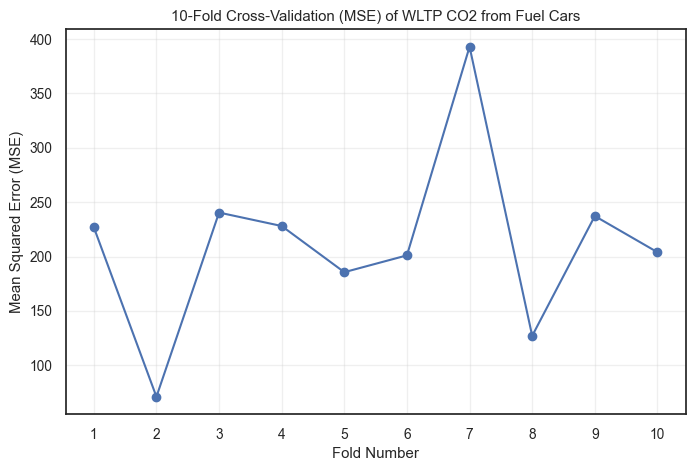

In [904]:
# data validation for fuel cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_fuel)

10-fold CV MSE scores: [196.263888695339, 166.97656776826773, 171.84763097495428, 236.30575475101722, 164.63380342084642, 171.42723437305426, 193.74103894193985, 585.9913886695763, 154.96234536980253, 197.3585544035697]
Mean MSE: 223.95082073683676
Validation MSE: 1400.8457844798568
Test MSE: 1293.3702178748638


Validation RMSE: 37.42787443176351
Test RMSE: 35.96345670086322


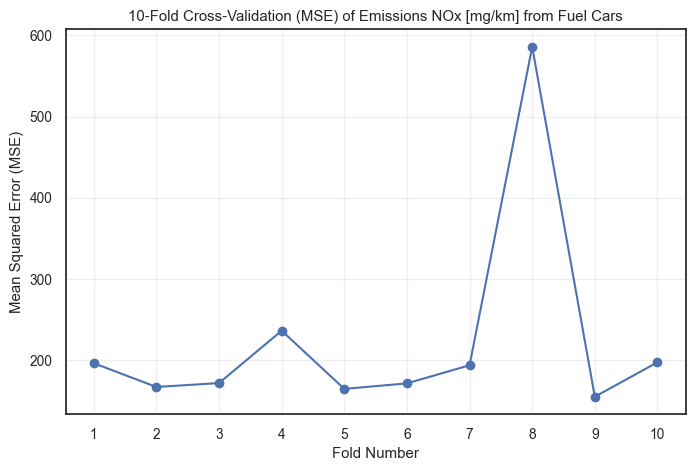

In [905]:
# data validation for fuel cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_fuel)

*Hybrid car data*

10-fold CV MSE scores: [1239.2532655144914, 1586.0682053838518, 1366.9974995948303, 1170.7755565874538, 1552.5254169525424, 1825.9652911355797, 1507.1878461500476, 1271.4742172473284, 970.3356191917294, 1391.3434076879907]
Mean MSE: 1388.1926325445847
Validation MSE: 1036.097747870503
Test MSE: 1539.9931032653658


Validation RMSE: 32.18847228233274
Test RMSE: 39.242745868062876


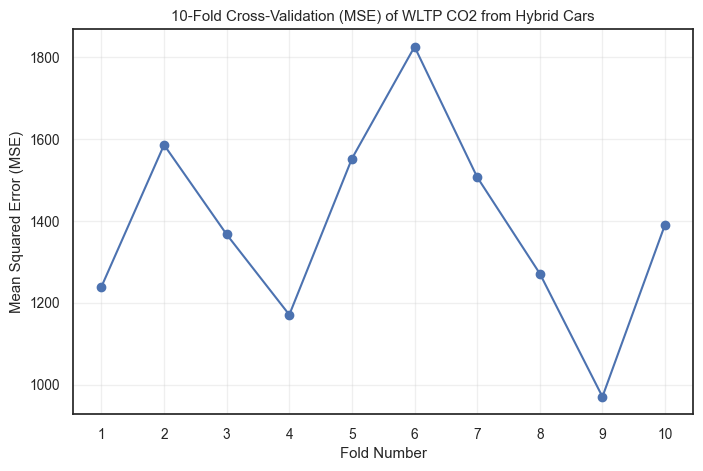

In [906]:
# data validation for hybrid cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_hybrid)

10-fold CV MSE scores: [42.27947119632712, 47.956806391015, 66.14828240354515, 57.94611387863636, 33.30093578990461, 42.873359949927355, 42.90273724034652, 36.751902710119815, 56.835284641779026, 39.163033607400436]
Mean MSE: 46.615792780900144
Validation MSE: 71.62983677331998
Test MSE: 24.3941498342779


Validation RMSE: 8.463441189806897
Test RMSE: 4.939043412876415


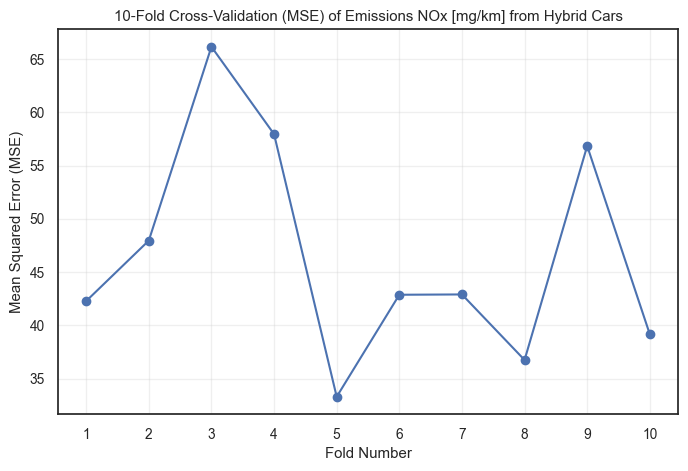

In [907]:
# data validation for hybrid cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_hybrid)

In [908]:
def feature_select_lasso(
    X_train, X_test, y_train, y_test, *,
    X_val=None, y_val=None,                    # <-- NEW (optional)
    validation_mode="merge",                   # "merge" or "separate"
    refit_after_cv=True,                       # only used when validation_mode="separate"
    features=None,
    dataset_name="Dataset",
    cv=10,
    random_state=42,
    max_iter=5000,
    show_plots=True
):
    """
    Lasso feature selection with 10-fold CV + learning curve.
    Supports 3-way split via `validation_mode`:
      - "merge":   CV+fit on train+val, test on test (recommended)
      - "separate":CV on train only; report val metrics; optionally refit on train+val
    """

    # --------- choose columns ---------
    use_cols = X_train.columns.tolist() if features is None else list(dict.fromkeys(features))
    for c in use_cols:
        if c not in X_train.columns: raise ValueError(f"Missing column in X_train: {c}")
    Xtr, Xte = X_train[use_cols].copy(), X_test[use_cols].copy()
    Xva = None if X_val is None else X_val[use_cols].copy()

    # --------- preprocessing ---------
    num_cols = Xtr.select_dtypes(include=["float64","int64"]).columns.tolist()
    cat_cols = [c for c in use_cols if c not in num_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="mean")),
                          ("sc",  StandardScaler())]), num_cols),
        ("cat", "drop", cat_cols)
    ])

    # --------- choose fitting data ---------
    if validation_mode == "merge" and X_val is not None and y_val is not None:
        Xfit = pd.concat([Xtr, Xva], axis=0)
        yfit = pd.concat([y_train, y_val], axis=0)
        fit_label = "train+val"
    else:
        Xfit, yfit = Xtr, y_train
        fit_label = "train"

    # --------- CV model on fitting data ---------
    cv_model = LassoCV(cv=cv, random_state=random_state, max_iter=max_iter)
    pipe_cv = Pipeline([("pre", pre), ("model", cv_model)])
    pipe_cv.fit(Xfit, yfit)
    alpha_star = pipe_cv.named_steps["model"].alpha_

    # --------- optional refit (separate mode) ---------
    final_pipe = pipe_cv
    if validation_mode == "separate" and refit_after_cv and X_val is not None and y_val is not None:
        # lock alpha and refit on train+val for the fairest test estimate
        final_model = Lasso(alpha=alpha_star, random_state=random_state, max_iter=max_iter)
        final_pipe = Pipeline([("pre", pre), ("model", final_model)])
        final_pipe.fit(pd.concat([Xtr, Xva]), pd.concat([y_train, y_val]))
        fit_label = "train+val (refit with fixed α)"

    # --------- predictions ---------
    yhat_tr = final_pipe.predict(Xtr)
    yhat_te = final_pipe.predict(Xte)
    yhat_va = None if Xva is None else final_pipe.predict(Xva)

    # --------- metrics (RSS + MSE) ---------
    rss_train = float(np.sum((y_train - yhat_tr)**2))
    mse_train = float(mean_squared_error(y_train, yhat_tr))
    rss_test  = float(np.sum((y_test  - yhat_te)**2))
    mse_test  = float(mean_squared_error(y_test,  yhat_te))

    rss_val = mse_val = None
    if Xva is not None and y_val is not None:
        rss_val = float(np.sum((y_val - yhat_va)**2))
        mse_val = float(mean_squared_error(y_val, yhat_va))

    print(f"\n==================== {dataset_name.upper()} ====================")
    print(f"Features ({len(use_cols)}): {use_cols}")
    print(f"Validation mode: {validation_mode} | Fitted on: {fit_label}")
    print(f"Chosen alpha (λ) from CV: {alpha_star:.6f}")
    if mse_val is not None:
        print(f"VAL  RSS: {rss_val:.2f} | VAL  MSE: {mse_val:.2f}")
    print(f"TRAIN RSS: {rss_train:.2f} | TRAIN MSE: {mse_train:.2f}")
    print(f"TEST  RSS: {rss_test:.2f} | TEST  MSE: {mse_test:.2f}")

    # --------- overfit check ---------
    ratio = rss_test / rss_train if rss_train>0 else np.inf
    gap   = (mse_test - mse_train)/mse_train*100 if mse_train>0 else np.inf
    status = "OK"
    if ratio>2 or gap>50: status="Possible overfit"
    elif ratio<0.6 and gap<-30: status="Well-regularised / easy test split"
    print(f"Overfit check → RSS ratio {ratio:.2f}, MSE gap {gap:.1f}% → {status}")

    # --------- learning curve (on the data used for CV) ---------
    train_sizes, tr_scores, va_scores = learning_curve(
        pipe_cv, Xfit, yfit, cv=cv, scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=random_state
    )
    lc_train = -tr_scores.mean(axis=1)
    lc_val   = -va_scores.mean(axis=1)

    # --------- plots ---------
    if show_plots:
        fig, axs = plt.subplots(2, 2, figsize=(12,8))
        fig.suptitle(f"{dataset_name} – LassoCV Diagnostics", fontsize=14, fontweight="bold")

        # CV curve from the CV model
        axs[0,0].semilogx(pipe_cv.named_steps["model"].alphas_,
                          pipe_cv.named_steps["model"].mse_path_.mean(axis=1), marker='.')
        axs[0,0].axvline(alpha_star, ls='--', color='r')
        axs[0,0].set_title(f"CV MSE vs Alpha ({cv}-fold)")
        axs[0,0].set_xlabel("Alpha (λ)"); axs[0,0].set_ylabel("Mean CV MSE")

        # Predicted vs Actual (test)
        axs[0,1].scatter(y_test, yhat_te)
        lo, hi = float(np.min(y_test)), float(np.max(y_test))
        axs[0,1].plot([lo, hi], [lo, hi], 'r--')
        axs[0,1].set_title("Predicted vs Actual (Test)")
        axs[0,1].set_xlabel("Actual WLTP CO2"); axs[0,1].set_ylabel("Predicted WLTP CO2")

        # Learning curve (on Xfit/yfit)
        axs[1,0].plot(train_sizes, lc_train, 'o-', label="Train MSE")
        axs[1,0].plot(train_sizes, lc_val,   's-', label="Validation MSE")
        axs[1,0].set_title(f"Learning Curve on {fit_label}")
        axs[1,0].set_xlabel("Training set size"); axs[1,0].set_ylabel("MSE"); axs[1,0].legend()

        # Coefficients
        coef = final_pipe.named_steps["model"].coef_
        names = final_pipe.named_steps["pre"].get_feature_names_out()
        axs[1,1].barh(names, coef); axs[1,1].set_title("Lasso Coefficients")
        axs[1,1].set_xlabel("Coefficient")
        plt.tight_layout(); plt.show()

    # --------- return ---------
    return {
        "dataset": dataset_name,
        "features": use_cols,
        "alpha": float(alpha_star),
        "mode": validation_mode,
        "fitted_on": fit_label,
        "rss_train": rss_train, "mse_train": mse_train,
        "rss_val": rss_val,     "mse_val": mse_val,
        "rss_test": rss_test,   "mse_test": mse_test,
        "overfit_flag": status,
        "learning_curve": {"train_sizes": train_sizes, "train_mse": lc_train, "val_mse": lc_val}
    }, final_pipe

In [909]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]
fuel_feats = ['Manual or Automatic', 'Engine Capacity', 'Engine Power (PS)', 'WLTP Metric Low', 'WLTP Metric Medium', 'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined', 'Emissions NOx [mg/km]']
#res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
#    X_train, X_test, y_train, y_test,
#    X_val=X_val, y_val=y_val,
#    validation_mode="separate",
#    features=fuel_feats, cv=10, show_plots=True
#)

In [910]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]
fuel_feats = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined']
#res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
#    X_train, X_test, y_train, y_test,
#    X_val=X_val, y_val=y_val,
#    validation_mode="separate",
#    features=fuel_feats, cv=10, show_plots=True
#)

In [911]:
# Example 2 — Hybrid: use all columns (features=None)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

#res_hybrid_all, pipe_hybrid_all = feature_select_lasso(
#    X_train, X_test, y_train, y_test,
#    X_val=X_val, y_val=y_val,
#    validation_mode="merge",
#    features=None, cv=10, show_plots=True
#)

In [912]:
# Example 3 — Lock alpha to a known value (e.g., from a previous CV run)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

#res_fuel_locked, pipe_fuel_locked = feature_select_lasso(
#    X_train, X_test, y_train, y_test,
#    X_val=X_val, y_val=y_val,
#    validation_mode="merge",
#    features=fuel_feats, cv=10, show_plots=True
#)

## Neural Network - Regression Tasks

**Variables Selection**
The following variables should be used to develop neural networks model.


In [913]:
#print current variables from the fuel cars dataset
print(data_fuel.columns)
print(data_fuel.shape)

Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1233, 12)


### Neural Network Regression (2 Layers)

Training RMSE: 11.83214538566079
Coefficient of determination (R²) on training data: 0.9541
Test RMSE: 43.92853084963061
Coefficient of determination (R²) on test data: 0.1397
Validation RMSE: 57.19261359806857
Coefficient of determination (R²) on  validation data: 0.1014


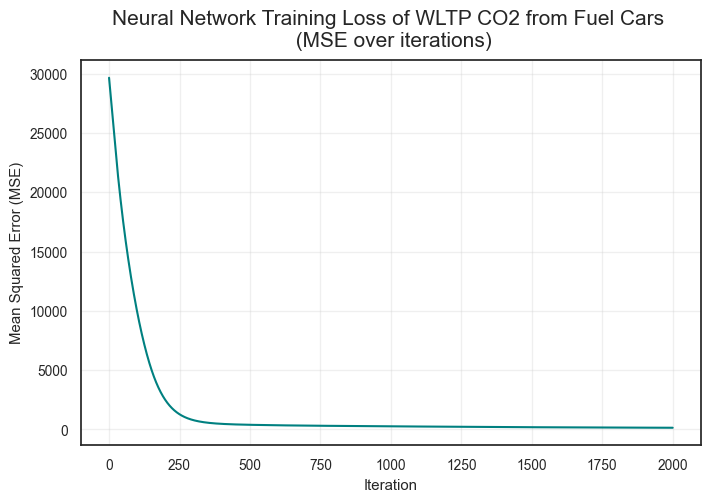

In [914]:
# Reusable function for Neural Network regression task - simple 1 hidden layer NN
def neural_network_regression(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    #reuse this part to access the splitted data.
    splits = data_split(target, data)

    # Access the data 
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)
    
    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features - 12
    D_out = 1 # number of outputs
    H = 20 # number of hidden neurons, based on number of features

    # Initialize weights
    W0 = normal(0, 0.1, size=(D_in, H))
    W1 = normal(0, 0.1, size=(H, D_out))

    # Training loop
    eta = 0.0005

    loss_history = []
    for i in range(2001):
        # forward pass
        
        ## Bias Terms
        b0 = np.zeros((1, H))
        b1 = np.zeros((1, 1))
        # z1 = X.dot(W0) + b0
        # a2 = a1.dot(W1) + b1

        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500)
        a1 = 1 / (1 + np.exp(-z1))
        a2 = a1.dot(W1) + b1
        Loss = np.mean((a2 - y_train) ** 2)
        loss_history.append(Loss)

        # # print loss every 100 iterations
        # if i % 100 == 0:
        #     print(f"Iteration {i}: Loss {Loss:.4f}")
    
        # backward pass
        da2 = 2.0 * (a2 - y_train)
        dW1 = a1.T.dot(da2) / N
        da1 = da2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train.T.dot(dz1) / N
        
        # update
        W0 -= eta * dW0 # weights update for features
        W1 -= eta * dW1

    # Evaluate
    z1 = X_train.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_pred = a1.dot(W1)

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1 = X_test.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_test_pred = a1.dot(W1)

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1 = X_val.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_val_pred = a1.dot(W1)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_fuel)

Training RMSE: 14.821462889091457
Coefficient of determination (R²) on training data: 0.1043
Test RMSE: 11.84380327307547
Coefficient of determination (R²) on test data: 0.0628
Validation RMSE: 12.432183269388801
Coefficient of determination (R²) on  validation data: 0.0942


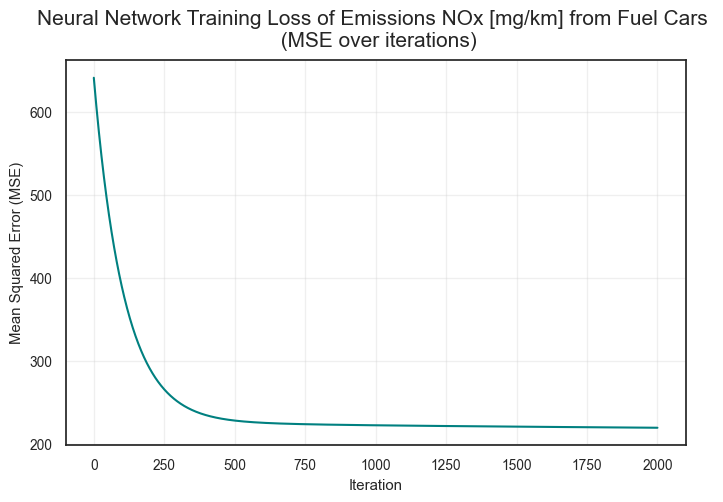

In [915]:
# Neural Network regression for fuel cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 38.45094043133957
Coefficient of determination (R²) on training data: 0.4958
Test RMSE: 38.71394959730473
Coefficient of determination (R²) on test data: 0.4605
Validation RMSE: 30.797058493922243
Coefficient of determination (R²) on  validation data: 0.5314


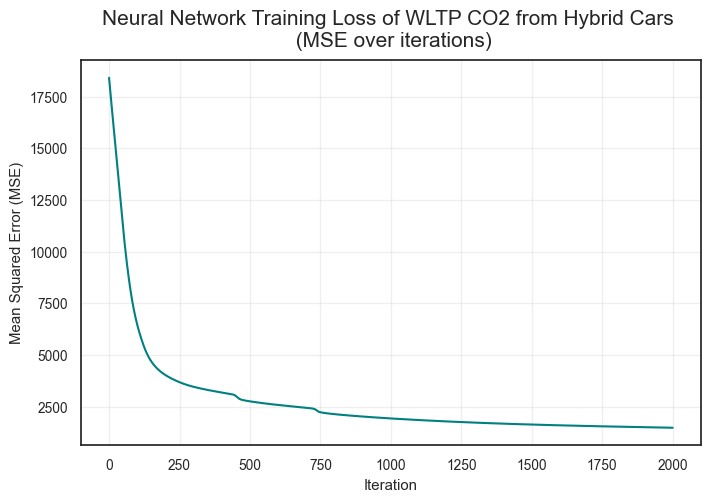

In [916]:
# Neural Network regression for hybrid cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_hybrid)

Training RMSE: 6.951501409137495
Coefficient of determination (R²) on training data: 0.358
Test RMSE: 4.555392989431061
Coefficient of determination (R²) on test data: 0.5398
Validation RMSE: 8.564928331625294
Coefficient of determination (R²) on  validation data: 0.2628


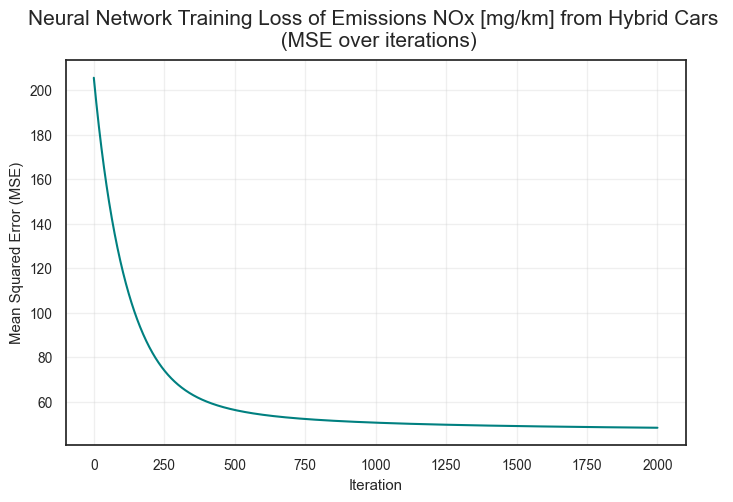

In [917]:
# Neural Network regression for hybrid cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_hybrid)

In [918]:
# #Examine weights from the NNR
# import io, contextlib

# buf = io.StringIO()
# with contextlib.redirect_stdout(buf):  # hide print outputs
#     res = neural_network_regression("WLTP CO2", data_fuel);

# # from your Regressor() output
# W0 = res["W0"]                    # shape: [n_features, H]
# features = res["features"]
# imp = np.mean(np.abs(W0), axis=1)

# print("W0 shape:", W0.shape)
# print("Number of features:", len(features))

# # Ensure they match in length
# min_len = min(len(features), len(imp))
# features = features[:min_len]
# imp = imp[:min_len]

# imp_df = pd.DataFrame({"Feature": features, "Importance": imp})
# imp_df = imp_df.sort_values(by="Importance", ascending=True)



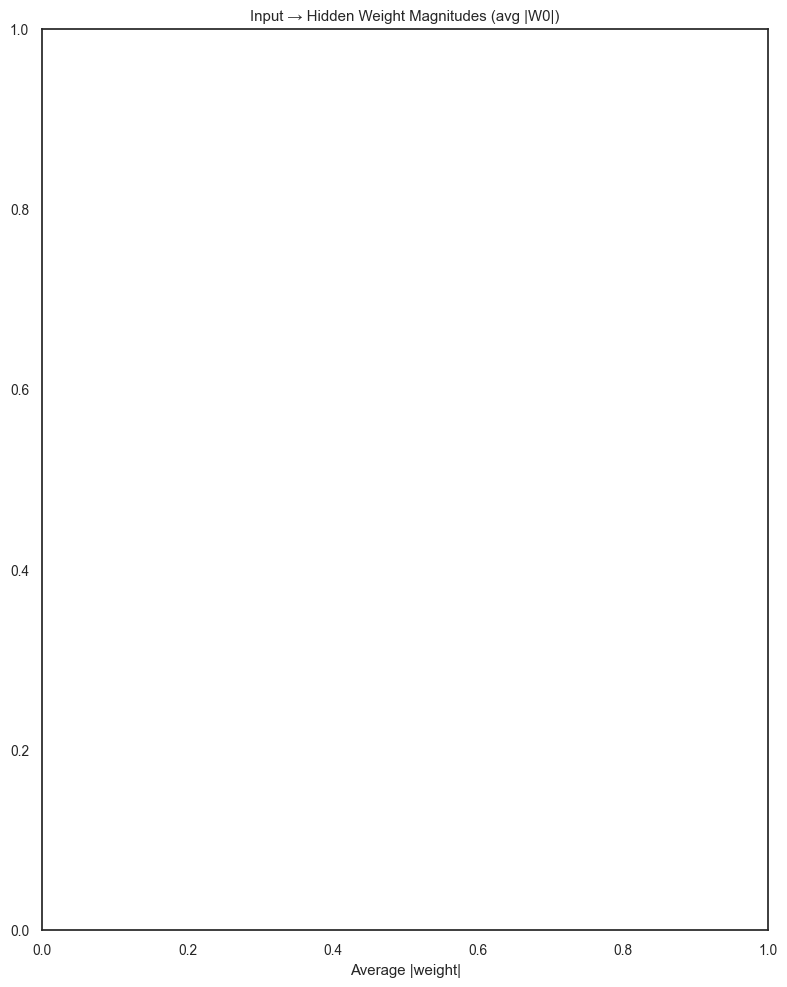

In [919]:
# importance = average absolute incoming weight to hidden layer
plt.figure(figsize=(8, 10))
#plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Input → Hidden Weight Magnitudes (avg |W0|)")
plt.xlabel("Average |weight|")
plt.tight_layout()
plt.show()

### Neural Network Regression - 3 Layers

Training RMSE: 15.622564437897724
Coefficient of determination (R²) on training data: 0.92
Test RMSE: 15.850467231513218
Coefficient of determination (R²) on test data: 0.888
Validation RMSE: 18.690134370355924
Coefficient of determination (R²) on  validation data: 0.904


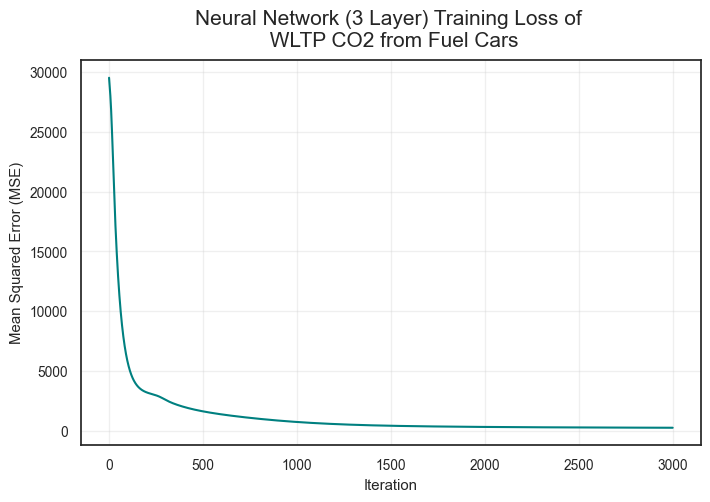

In [920]:
# Reusable function for Neural Network regression task - 2 hidden layer NN
def neural_network_regression_2hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    splits = data_split(target, data)

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]      

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)

    # scaler = StandardScaler()
    # X_train_scaled = scaler.fit_transform(X_train)
    # X_test_scaled = scaler.transform(X_test)
    # X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    H1 = 30 # number of hidden neurons in hidden layer 1
    H2 = 20 # number of hidden neurons in hidden layer 2

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Output: hidden2 -> output
    W2 = normal(0, 0.1, size=(H2, D_out))
    b2 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0003

    loss_history = []
    for i in range(3001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1.0 / (1.0 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1.0 / (1.0 + np.exp(-z2)) # sigmoid

        # Output (linear)
        y_hat = a2.dot(W2) + b2

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))

        # ---- backward pass ----
        # dLoss/dy_hat = 2*(y_hat - y) / N
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a2 -> y_hat)
        dW2 = a2.T.dot(dy)     
        db2 = np.sum(dy, axis=0, keepdims=True) 

        # Backprop into hidden2
        da2 = dy.dot(W2.T)                        
        dz2 = da2 * a2 * (1.0 - a2)               
        dW1 = a1.T.dot(dz2)                       
        db1 = np.sum(dz2, axis=0, keepdims=True)  

        # Backprop into hidden1
        da1 = dz2.dot(W1.T)                       
        dz1 = da1 * a1 * (1.0 - a1)               
        dW0 = X_train.T.dot(dz1)           
        db0 = np.sum(dz1, axis=0, keepdims=True) 

        # ---- update parameters ----
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1
        W0 -= eta * dW0
        b0 -= eta * db0

    # # Evaluate
    # z1 = X_train_scaled.dot(W0)
    # z1 = np.clip(z1, -500, 500)
    # a1 = 1 / (1 + np.exp(-z1))
    # y_pred = a1.dot(W2)

    # Evaluate on training set
    z1_ = X_train.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    
    y_pred = a2_.dot(W2) + b2

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1_ = X_test.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_test_pred = a2_.dot(W2) + b2

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1_ = X_val.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_val_pred = a2_.dot(W2) + b2
    
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (3 Layer) Training Loss of \n {target} from {data_label}",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_2hidden("WLTP CO2", data_fuel)

Training RMSE: 15.393607895371947
Coefficient of determination (R²) on training data: 0.0338
Test RMSE: 12.28769373326525
Coefficient of determination (R²) on test data: -0.0088
Validation RMSE: 12.82621176054791
Coefficient of determination (R²) on  validation data: 0.0358


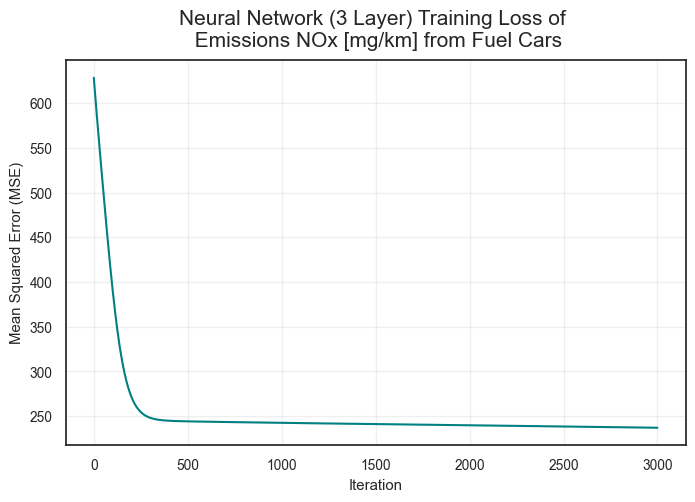

In [921]:
# NN Regression (2 hidden layers), Emissions NOx from Fuel cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 35.42839109030671
Coefficient of determination (R²) on training data: 0.5719
Test RMSE: 32.62246511055373
Coefficient of determination (R²) on test data: 0.6169
Validation RMSE: 32.63765510527334
Coefficient of determination (R²) on  validation data: 0.4737


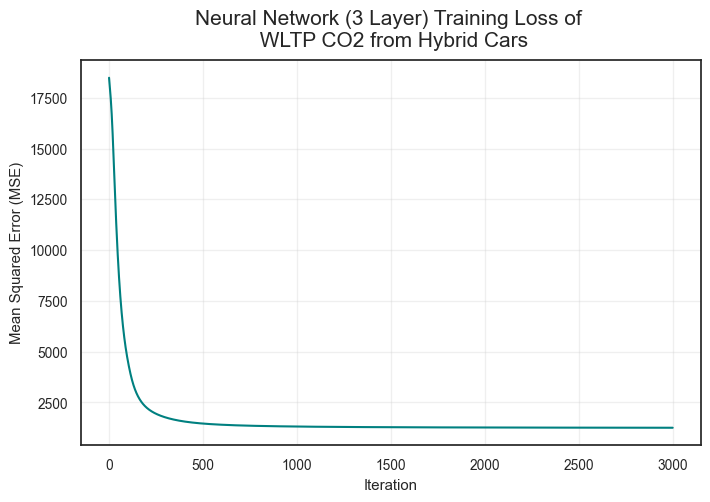

In [922]:
# NN Regression (2 hidden layers), CO2 emissions from Hybrid cars
neural_network_regression_2hidden("WLTP CO2", data_hybrid)

Training RMSE: 8.005424250010037
Coefficient of determination (R²) on training data: 0.1486
Test RMSE: 5.914581063728446
Coefficient of determination (R²) on test data: 0.2243
Validation RMSE: 9.415363072073598
Coefficient of determination (R²) on  validation data: 0.1092


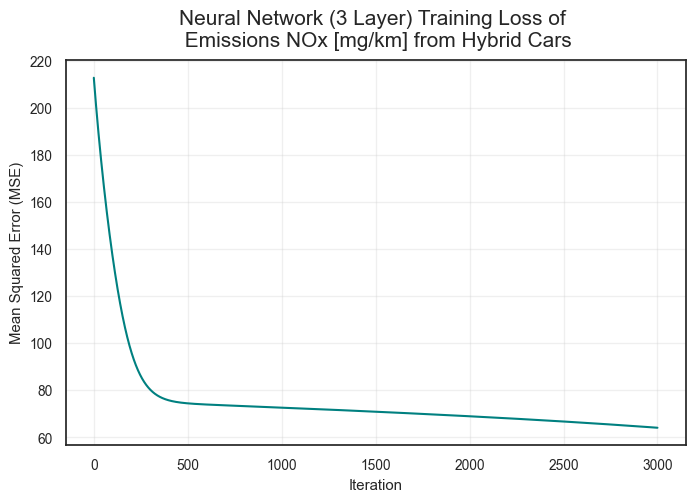

In [923]:
# NN Regression (2 hidden layers), Emissions NOx from Hybrid cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_hybrid)

### Neural Network Regression - 4 Layers

Training RMSE: 138.1645823541116
Coefficient of determination (R²) on training data: -5.2572
Test RMSE: 138.67875772052057
Coefficient of determination (R²) on test data: -7.5738
Validation RMSE: 146.49132268610106
Coefficient of determination (R²) on  validation data: -4.8955


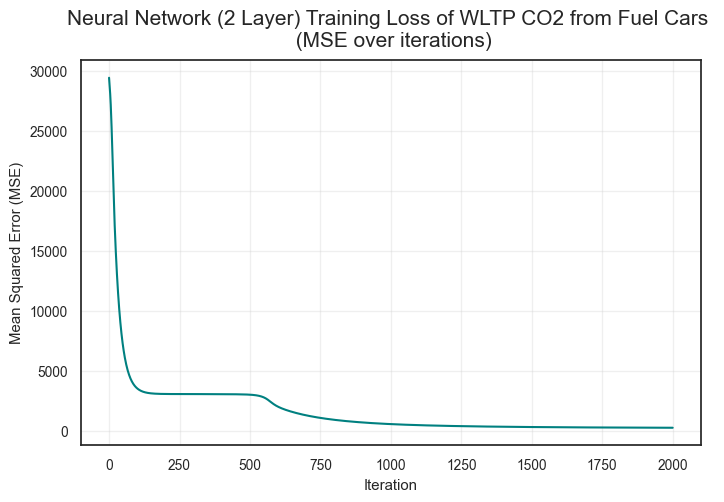

In [924]:
# Reusable function for Neural Network regression task - 3 hidden layer NN

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def neural_network_regression_3hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Perform data splitting
    splits = data_split(target, data)   
    
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]
    
    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)


    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    
    H1 = 40 # number of hidden neurons in hidden layer 1
    H2 = 30 # number of hidden neurons in hidden layer 2
    H3 = 20 # number of hidden neurons in hidden layer 3

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Layer 3: hidden2 -> hidden3
    W2 = normal(0, 0.1, size=(H2, H3))
    b2 = np.zeros((1, H3))

    # Output: hidden3 -> output
    W3 = normal(0, 0.1, size=(H3, D_out))
    b3 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0005

    loss_history = []
    for i in range(2001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1 / (1 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1 / (1 + np.exp(-z2)) # sigmoid

        # Layer 3
        z3 = a2.dot(W2) + b2
        z3 = np.clip(z3, -500, 500)
        a3 = 1 / (1 + np.exp(-z3)) # sigmoid

        # Output (linear)
        y_hat = a3.dot(W3) + b3

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))


        # ---- backward pass ----
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a3 -> y_hat)
        dW3 = a3.T.dot(dy)       
        db3 = np.sum(dy, axis=0, keepdims=True)

        # Backprop into hidden3
        da3 = dy.dot(W3.T)
        dz3 = da3 * a3 * (1 - a3)
        dW2 = a2.T.dot(dz3)
        db2 = np.sum(dz3, axis=0, keepdims=True)
        
        # Backprop into hidden2
        da2 = dz3.dot(W2.T)
        dz2 = da2 * a2 * (1 - a2)
        dW1 = a1.T.dot(dz2)
        db1 = np.sum(dz2, axis=0, keepdims=True)
        
        # Backprop into hidden1
        da1 = dz2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)
 
        # ---- update parameters ----
        W3 -= eta * dW3
        b3 -= eta * db3
        
        W2 -= eta * dW2
        b2 -= eta * db2
        
        W1 -= eta * dW1
        b1 -= eta * db1
        
        W0 -= eta * dW0
        b0 -= eta * db0

    # Evaluate on training set
    def predict(X):
        z1 = X.dot(W0) + b0
        z1_ = np.clip(z1, -500, 500)
        a1 = 1.0 / (1.0 + np.exp(-z1_))
        
        z2 = a1.dot(W1) + b1
        z2_ = np.clip(z2, -500, 500)
        a2 = np.clip(z2_, -500, 500)
        
        z3 = a2.dot(W2) + b2
        z3_ = np.clip(z3, -500, 500)
        a3 = 1.0 / (1.0 + np.exp(-z3_))

        return a3.dot(W3) + b3

    
    # z1 = X_train_scaled.dot(W0) + b0
    # z1_ = np.clip(z1, -500, 500)
    # a1 = 1.0 / (1.0 + np.exp(-z1_))
        
    # z2 = a1.dot(W1) + b1
    # z2_ = np.clip(z2, -500, 500)
    # a2 = np.clip(z2_, -500, 500)
    
    # z3 = a2.dot(W2) + b2
    # z3_ = np.clip(z3, -500, 500)
    # a3 = 1.0 / (1.0 + np.exp(-z3_))
    # y_train_pred = a3.dot(W3) + b3

    # MSE and RMSE on training data
    y_train_pred = predict(X_train)
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_train_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test)
    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layer) Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_3hidden("WLTP CO2", data_fuel)

Training RMSE: 15.601972032883996
Coefficient of determination (R²) on training data: 0.0075
Test RMSE: 12.140231683389397
Coefficient of determination (R²) on test data: 0.0153
Validation RMSE: 12.977859002448692
Coefficient of determination (R²) on  validation data: 0.0129


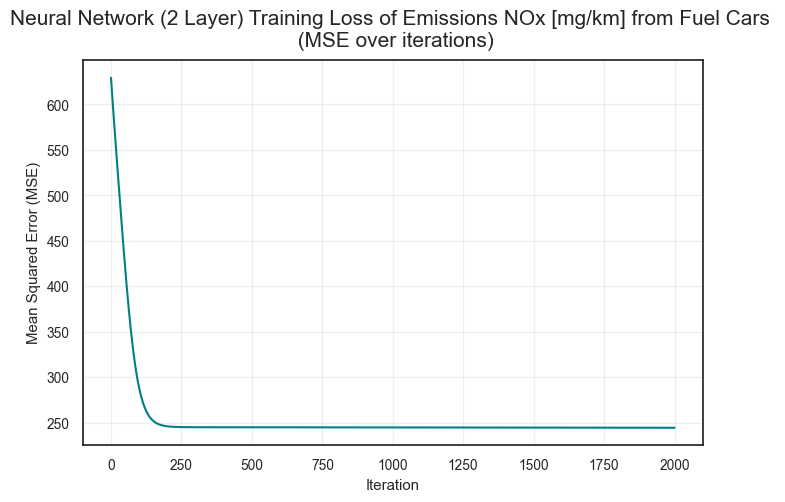

In [925]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 35.56435477602406
Coefficient of determination (R²) on training data: 0.5687
Test RMSE: 32.2759250197809
Coefficient of determination (R²) on test data: 0.625
Validation RMSE: 32.67101399065757
Coefficient of determination (R²) on  validation data: 0.4726


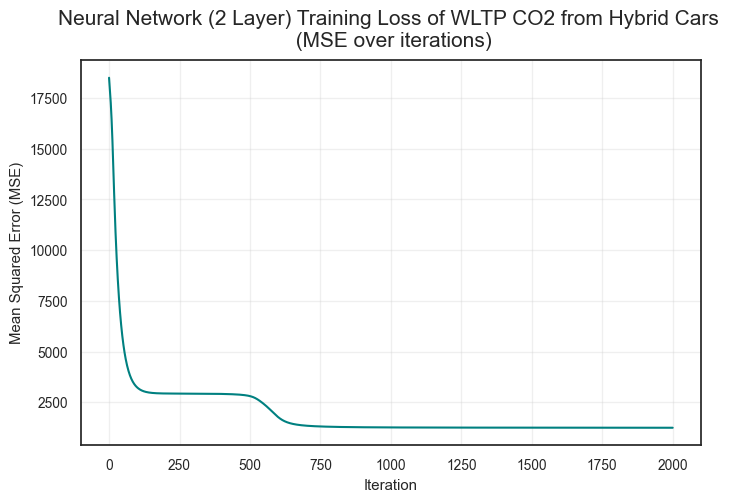

In [926]:
neural_network_regression_3hidden("WLTP CO2", data_hybrid)

Training RMSE: 8.549650805680743
Coefficient of determination (R²) on training data: 0.0289
Test RMSE: 6.486216803484162
Coefficient of determination (R²) on test data: 0.0671
Validation RMSE: 9.968267522196147
Coefficient of determination (R²) on  validation data: 0.0015


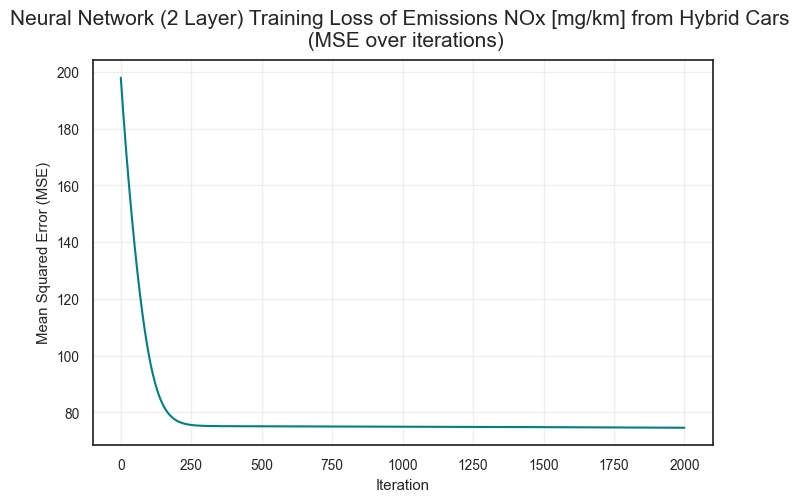

In [927]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_hybrid)

# References
- European Environment Agency, 2023, 'Greenhouse Gas Emissions from Transport in Europe.', _EEA Report No. 23/2023_, Publications Office of the European Union.

- Intergovernmental Panel on Climate Change (IPCC), 2022, 'Climate Change 2022: Mitigation of Climate Change', _Contribution of Working Group III to the Sixth Assessment Report of the IPCC_, Cambridge University Press.

- UK Vehicle Certification Agency, 2024, _Fuel Consumption and Emission Data Tables: Car Fuel and CO₂ Information. Department for Transport_, viewed 29 September 2025, <https://www.vehicle-certification-agency.gov.uk/>

- World Health Organization, 2021, _WHO Global Air Quality Guidelines: Particulate Matter, Ozone, Nitrogen Dioxide, Sulfur Dioxide and Carbon Monoxide_, Geneva: WHO.

- U.S. Environmental Protection Agency (EPA), 2023, _Nitrogen Oxides (NOₓ) Pollution_, EPA.

- European Environment Agency (EEA), 2022, _Air Pollution Sources — Volatile Organic Compounds (VOCs)_, EEA Report

- Veza, Ibham et al, 2023, 'Electric Vehicle (EV) and Driving Towards Sustainability: Comparison between EV, HEV, PHEV, and ICE Vehicles to Achieve Net Zero Emissions by 2050 from EV', _Alexandria Engineering Journal_, vol. 82, pp. 459–467, DOI.10.1016/j.aej.2023.10.020

